In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Features:
- Price Ratio: ClosePrice / OriginalListPrice
    - Measures negotiation strength
- Price Per Sq Ft: ClosePrice / LivingArea
    - Normalizes price across sizes
- Days on Market: DaysonMarket (raw field)
    - Time-to-sell indicator
- Year / Month / YrMo: Derived from CloseDate
    - Enables time-series analysis
- Close to Original List Ratio: ClosePrice / OriginalListPrice
    - Captures full price reduction history
- Listing to Contract Days: PurchaseContractDate - ListingContractDate
    - Measures time from listing to accepted offer
- Contract to Close Days: CloseDate - PurchaseContractDate
    - Escrow and closing period duration

In [2]:
sold_cleaned_df = pd.read_csv("../data/Sold/sold_cleaned.csv")
sold_cleaned_df.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,listing_after_close_flag,purchase_after_close_flag,negative_timeline_flag,price_ratio,price_per_sqft,Month,YrMo,CloseToOriginalListRatio,ListingToContractDays,ContractToCloseDays
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,False,False,False,0.480962,210.526316,1,2024-01,0.480962,777 days,65 days
1,SanDiego,SanDiego,Missing,False,False,759900.0,522107581,mdarwich12@gmail.com,2024-01-05,815000.0,...,False,False,False,1.072510,412.867275,1,2024-01,1.072510,114 days,919 days
2,SanDiego,SanDiego,"Carpet,Laminate,Tile",True,False,4200.0,518850317,nanloz@yahoo.com,2024-01-17,4500.0,...,False,False,False,1.071429,1.587862,1,2024-01,1.071429,986 days,0 days
3,Laguna,Laguna,"Carpet,Tile",True,False,5500.0,518662094,Sydney@Agentsyd.com,2024-01-29,1200.0,...,False,False,False,0.218182,0.487409,1,2024-01,0.218182,1004 days,0 days
4,SanDiego,SanDiego,Missing,False,False,739900.0,510919001,mdarwich12@gmail.com,2024-01-05,810000.0,...,False,False,False,1.094743,410.334347,1,2024-01,1.094743,255 days,778 days


In [3]:
sold_cleaned_df['price_ratio'] = sold_cleaned_df['ClosePrice'] / sold_cleaned_df['OriginalListPrice']
sold_cleaned_df[sold_cleaned_df['price_ratio'].notna()].head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,listing_after_close_flag,purchase_after_close_flag,negative_timeline_flag,price_ratio,price_per_sqft,Month,YrMo,CloseToOriginalListRatio,ListingToContractDays,ContractToCloseDays
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,False,False,False,0.480962,210.526316,1,2024-01,0.480962,777 days,65 days
1,SanDiego,SanDiego,Missing,False,False,759900.0,522107581,mdarwich12@gmail.com,2024-01-05,815000.0,...,False,False,False,1.072510,412.867275,1,2024-01,1.072510,114 days,919 days
2,SanDiego,SanDiego,"Carpet,Laminate,Tile",True,False,4200.0,518850317,nanloz@yahoo.com,2024-01-17,4500.0,...,False,False,False,1.071429,1.587862,1,2024-01,1.071429,986 days,0 days
3,Laguna,Laguna,"Carpet,Tile",True,False,5500.0,518662094,Sydney@Agentsyd.com,2024-01-29,1200.0,...,False,False,False,0.218182,0.487409,1,2024-01,0.218182,1004 days,0 days
4,SanDiego,SanDiego,Missing,False,False,739900.0,510919001,mdarwich12@gmail.com,2024-01-05,810000.0,...,False,False,False,1.094743,410.334347,1,2024-01,1.094743,255 days,778 days


In [4]:
sold_cleaned_df.shape

(585283, 76)

In [5]:
sold_cleaned_df['price_per_sqft'] = sold_cleaned_df['ClosePrice'] / sold_cleaned_df['LivingArea']
sold_cleaned_df[sold_cleaned_df['price_per_sqft'].notna()].head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,listing_after_close_flag,purchase_after_close_flag,negative_timeline_flag,price_ratio,price_per_sqft,Month,YrMo,CloseToOriginalListRatio,ListingToContractDays,ContractToCloseDays
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,False,False,False,0.480962,210.526316,1,2024-01,0.480962,777 days,65 days
1,SanDiego,SanDiego,Missing,False,False,759900.0,522107581,mdarwich12@gmail.com,2024-01-05,815000.0,...,False,False,False,1.072510,412.867275,1,2024-01,1.072510,114 days,919 days
2,SanDiego,SanDiego,"Carpet,Laminate,Tile",True,False,4200.0,518850317,nanloz@yahoo.com,2024-01-17,4500.0,...,False,False,False,1.071429,1.587862,1,2024-01,1.071429,986 days,0 days
3,Laguna,Laguna,"Carpet,Tile",True,False,5500.0,518662094,Sydney@Agentsyd.com,2024-01-29,1200.0,...,False,False,False,0.218182,0.487409,1,2024-01,0.218182,1004 days,0 days
4,SanDiego,SanDiego,Missing,False,False,739900.0,510919001,mdarwich12@gmail.com,2024-01-05,810000.0,...,False,False,False,1.094743,410.334347,1,2024-01,1.094743,255 days,778 days


In [6]:
sold_cleaned_df['price_per_sqft'].isna().sum()

np.int64(1)

In [7]:
sold_cleaned_df[sold_cleaned_df['CloseDate'].notna()]['CloseDate'].head()

0    2024-01-26
1    2024-01-05
2    2024-01-17
3    2024-01-29
4    2024-01-05
Name: CloseDate, dtype: str

In [8]:
sold_cleaned_df['CloseDate'] = pd.to_datetime(sold_cleaned_df['CloseDate'])

In [9]:
sold_cleaned_df['Month'] = sold_cleaned_df['CloseDate'].dt.month

In [10]:
sold_cleaned_df['Month'].isna().sum()

np.int64(0)

In [11]:
sold_cleaned_df['Year'] = sold_cleaned_df['CloseDate'].dt.year

In [12]:
sold_cleaned_df['Year'].isna().sum()

np.int64(0)

In [13]:
sold_cleaned_df['CloseDate'].isna().sum()

np.int64(0)

In [14]:
sold_cleaned_df['YrMo'] = sold_cleaned_df['CloseDate'].dt.to_period('M')

In [15]:
sold_cleaned_df['YrMo'].isna().sum()

np.int64(0)

In [16]:
sold_cleaned_df[sold_cleaned_df['YrMo'].notna()]['YrMo'].head()

0    2024-01
1    2024-01
2    2024-01
3    2024-01
4    2024-01
Name: YrMo, dtype: period[M]

In [17]:
sold_cleaned_df['CloseToOriginalListRatio'] = sold_cleaned_df['ClosePrice'] / sold_cleaned_df['OriginalListPrice']

In [18]:
sold_cleaned_df['CloseToOriginalListRatio'].isna().sum()

np.int64(0)

In [19]:
sold_cleaned_df['PurchaseContractDate'] = pd.to_datetime(sold_cleaned_df['PurchaseContractDate'])

In [20]:
sold_cleaned_df['ListingContractDate'] = pd.to_datetime(sold_cleaned_df['ListingContractDate'])

In [21]:
sold_cleaned_df['ListingToContractDays'] = sold_cleaned_df['PurchaseContractDate'] - sold_cleaned_df['ListingContractDate']

In [22]:
sold_cleaned_df['ListingToContractDays'].isna().sum()

np.int64(12199)

In [23]:
sold_cleaned_df[sold_cleaned_df['ListingToContractDays'].notna()]['ListingToContractDays'].head()

0    777 days
1    114 days
2    986 days
3   1004 days
4    255 days
Name: ListingToContractDays, dtype: timedelta64[us]

In [24]:
sold_cleaned_df['ContractToCloseDays'] = sold_cleaned_df['CloseDate'] - sold_cleaned_df['PurchaseContractDate']

In [25]:
sold_cleaned_df[sold_cleaned_df['ContractToCloseDays'].notna()]['ContractToCloseDays'].head()

0    65 days
1   919 days
2     0 days
3     0 days
4   778 days
Name: ContractToCloseDays, dtype: timedelta64[us]

In [26]:
sold_cleaned_df['ContractToCloseDays'].isna().sum()

np.int64(12199)

#### **Segment Analysis**

Property Segmentation

In [27]:
property_summary = (
    sold_cleaned_df.groupby(['PropertyType', 'PropertySubType'])
    .agg(
        sales_count=('ClosePrice', 'count'),
        median_close_price=('ClosePrice', 'median'),
        avg_close_price=('ClosePrice', 'mean'),
        avg_price_per_sqft=('price_per_sqft', 'mean'),
        median_dom=('DaysOnMarket', 'median'),
        avg_sale_to_list=('price_ratio', 'mean')
    )
    .reset_index()
)

A. Market Heat Score
- Higher measures mean stronger demand and faster movement

In [28]:
property_summary['market_heat_score'] = (property_summary['avg_sale_to_list'] / property_summary['median_dom'])

In [29]:
property_summary[property_summary['market_heat_score'] != float('inf')]['market_heat_score'].describe()

count    74.000000
mean      1.110802
std       4.938004
min       0.003193
25%       0.017582
50%       0.033755
75%       0.054155
max      35.925278
Name: market_heat_score, dtype: float64

In [30]:
property_summary[property_summary['market_heat_score'] > 72]

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score
6,CommercialLease,Retail,110,2980.0,3.989324e+04,25.280886,94.5,inf,inf
28,ManufacturedInPark,SingleFamilyResidence,15957,175000.0,2.072598e+05,inf,41.0,inf,inf
43,Residential,SingleFamilyResidence,304600,885000.0,1.238957e+06,inf,17.0,inf,inf
66,ResidentialLease,ManufacturedHome,17,2000.0,1.996765e+03,1.584750,0.0,0.971394,inf
73,ResidentialLease,SingleFamilyResidence,67560,4400.0,1.037055e+04,inf,25.0,inf,inf


In [31]:
property_summary[property_summary['market_heat_score'] < 0.07].head()

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score
0,BusinessOpportunity,SingleFamilyResidence,99,165000.0,440667.676768,279.257083,67.0,0.751461,0.011216
1,CommercialLease,Agriculture,1,27000.0,27000.000000,17.110266,302.0,0.964286,0.003193
2,CommercialLease,Business,16,2525.0,2569.750000,1.628485,55.5,0.955272,0.017212
8,CommercialLease,SpecialPurpose,7,3500.0,3700.000000,2.344740,34.0,0.914099,0.026885
9,CommercialLease,UnimprovedLand,1,1000.0,1000.000000,0.633714,97.0,0.800000,0.008247


B. Premium vs. Discount
- Shows whether homes sell above or below asking. 
- Ex: 
    - +3% -> bidding wars
    - -5% -> price negotiation pressure

In [32]:
property_summary['premium_discount_pct'] = ((property_summary['avg_sale_to_list'] - 1) * 100)

In [33]:
property_summary[property_summary['premium_discount_pct'] < 0].head()

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct
0,BusinessOpportunity,SingleFamilyResidence,99,165000.0,440667.676768,279.257083,67.0,0.751461,0.011216,-24.853945
1,CommercialLease,Agriculture,1,27000.0,27000.000000,17.110266,302.0,0.964286,0.003193,-3.571429
2,CommercialLease,Business,16,2525.0,2569.750000,1.628485,55.5,0.955272,0.017212,-4.472752
8,CommercialLease,SpecialPurpose,7,3500.0,3700.000000,2.344740,34.0,0.914099,0.026885,-8.590062
9,CommercialLease,UnimprovedLand,1,1000.0,1000.000000,0.633714,97.0,0.800000,0.008247,-20.000000


In [34]:
property_summary.groupby('PropertyType')['premium_discount_pct'].mean()

PropertyType
BusinessOpportunity   -2.485395e+01
CommercialLease                 inf
CommercialSale         1.684334e+04
Land                  -2.863463e+00
ManufacturedInPark              inf
Residential                     inf
ResidentialIncome      1.995983e+03
ResidentialLease                inf
Name: premium_discount_pct, dtype: float64

In [35]:
property_summary.nsmallest(1, 'premium_discount_pct')

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct
0,BusinessOpportunity,SingleFamilyResidence,99,165000.0,440667.676768,279.257083,67.0,0.751461,0.011216,-24.853945


In [36]:
property_summary[property_summary['premium_discount_pct'] > 0].head()

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct
3,CommercialLease,Industrial,40,4131.5,126820.989500,80.368181,66.5,11.431652,0.171905,1.043165e+03
4,CommercialLease,MixedUse,107,3000.0,6614.523364,4.191713,82.0,8.847253,0.107893,7.847253e+02
5,CommercialLease,Office,136,2437.5,48854.322206,30.959647,99.5,739.980612,7.436991,7.389806e+04
6,CommercialLease,Retail,110,2980.0,39893.237727,25.280886,94.5,inf,inf,inf
7,CommercialLease,SingleFamilyResidence,257,2662.5,20856.202724,13.206987,74.0,9.408837,0.127146,8.408837e+02


In [37]:
property_summary.nlargest(1, 'premium_discount_pct')

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct
6,CommercialLease,Retail,110,2980.0,39893.237727,25.280886,94.5,inf,inf,inf


C. Relative Liquity Score
- Lower DOM = more liquid market

In [38]:
property_summary['liquidity_score'] = (
    1 / property_summary['median_dom']
)

In [39]:
property_summary['liquidity_score'].describe()

C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    79.000000
mean           inf
std            NaN
min       0.003311
25%       0.016261
50%       0.028571
75%       0.040833
max            inf
Name: liquidity_score, dtype: float64

In [40]:
max_liquidity = property_summary[property_summary['liquidity_score'] != float('inf')]['liquidity_score'].max()
max_liquidity

np.float64(0.10526315789473684)

In [41]:
property_summary[property_summary['liquidity_score'] == max_liquidity]

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score
13,CommercialSale,Farm,2,1650000.0,1650000.0,1045.627376,9.5,0.966667,0.101754,-3.333333,0.105263


Commerical Lease and Residential Lease houses tend to sell faster

In [42]:
min_liquidity = property_summary['liquidity_score'].min()
min_liquidity

np.float64(0.0033112582781456954)

In [43]:
property_summary[property_summary['liquidity_score'] == min_liquidity]

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score
1,CommercialLease,Agriculture,1,27000.0,27000.0,17.110266,302.0,0.964286,0.003193,-3.571429,0.003311


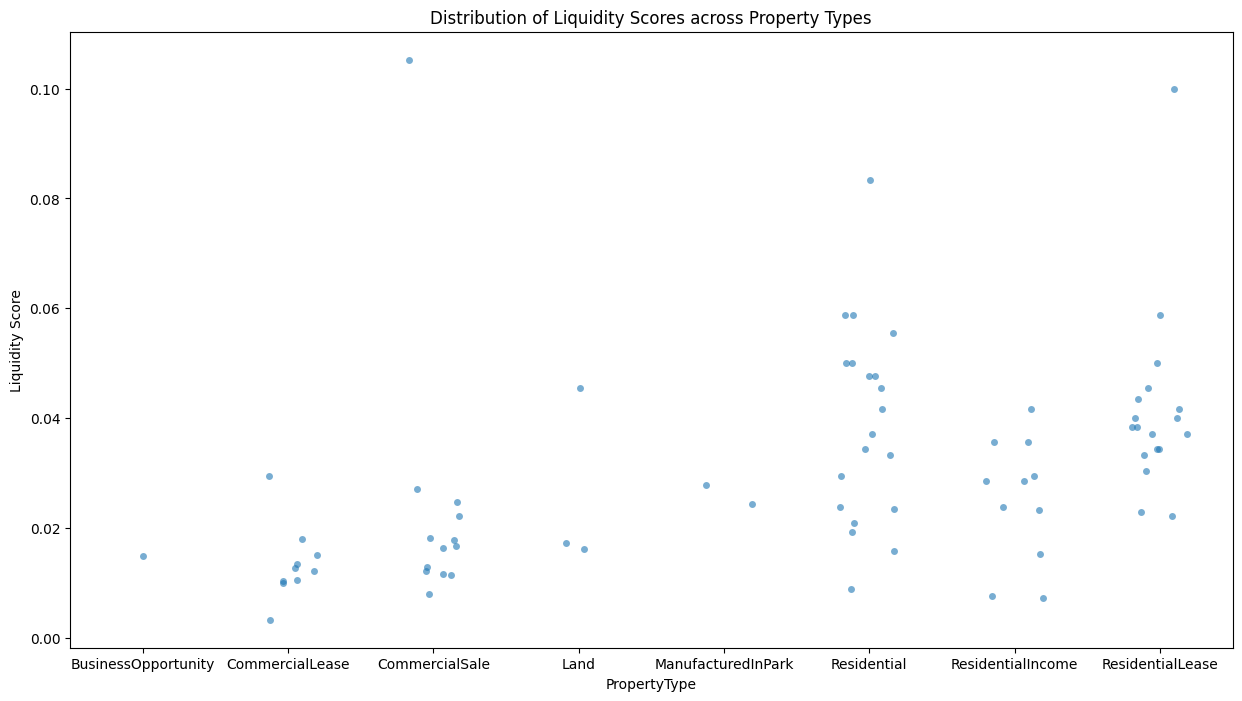

In [44]:
plt.figure(figsize=(15, 8))

sns.stripplot(
    x="PropertyType",
    y="liquidity_score",
    data=property_summary,
    jitter=0.2, 
    alpha=0.6,
)

plt.title("Distribution of Liquidity Scores across Property Types")
plt.ylabel("Liquidity Score")
plt.show()

Most Expensive

In [45]:
expensive_segments = property_summary.sort_values(
    by='median_close_price',
    ascending=False
)
expensive_segments.head()

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score
16,CommercialSale,MixedUse,407,2100000.0,2.640716e+06,1673.457714,60.0,0.896433,0.014941,-10.356656,0.016667
49,ResidentialIncome,Apartment,1399,1850000.0,2.515178e+06,1593.902581,42.0,0.932806,0.022210,-6.719394,0.023810
17,CommercialSale,MultiFamily,67,1810000.0,2.182558e+06,1383.116367,45.0,0.894904,0.019887,-10.509639,0.022222
13,CommercialSale,Farm,2,1650000.0,1.650000e+06,1045.627376,9.5,0.966667,0.101754,-3.333333,0.105263
23,CommercialSale,Warehouse,25,1600000.0,2.056746e+06,1303.387833,55.0,0.836220,0.015204,-16.377984,0.018182


Fastest Selling

In [46]:
faster_segments = property_summary.sort_values(
    by='median_dom',
    ascending=False
)
faster_segments.head()

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score
1,CommercialLease,Agriculture,1,27000.0,27000.0,17.110266,302.0,0.964286,0.003193,-3.571429,0.003311
55,ResidentialIncome,OwnYourOwn,2,215000.0,215000.0,136.248416,139.0,0.798565,0.005745,-20.143469,0.007194
50,ResidentialIncome,Cabin,1,314000.0,314000.0,198.986058,131.0,0.957317,0.007308,-4.268293,0.007634
12,CommercialSale,Duplex,1,550000.0,550000.0,348.542459,125.0,0.949914,0.007599,-5.008636,0.008000
46,Residential,Timeshare,10,39500.0,188050.0,299.463275,112.0,0.848493,0.007576,-15.150699,0.008929


In [47]:
def classify_market(row):

    if row['market_heat_score'] > 0.02:
        return 'Hot Market'

    elif row['market_heat_score'] > 0.01:
        return 'Balanced'

    else:
        return 'Slow Market'

property_summary['market_category'] = (
    property_summary.apply(classify_market, axis=1)
)

In [48]:
property_summary['market_category'].value_counts()

market_category
Hot Market     57
Balanced       16
Slow Market     6
Name: count, dtype: int64

In [49]:
hot_market = property_summary[property_summary['market_category'] == "Hot Market"]
hot_market.head()

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score,market_category
3,CommercialLease,Industrial,40,4131.5,126820.989500,80.368181,66.5,11.431652,0.171905,1.043165e+03,0.015038,Hot Market
4,CommercialLease,MixedUse,107,3000.0,6614.523364,4.191713,82.0,8.847253,0.107893,7.847253e+02,0.012195,Hot Market
5,CommercialLease,Office,136,2437.5,48854.322206,30.959647,99.5,739.980612,7.436991,7.389806e+04,0.010050,Hot Market
6,CommercialLease,Retail,110,2980.0,39893.237727,25.280886,94.5,inf,inf,inf,0.010582,Hot Market
7,CommercialLease,SingleFamilyResidence,257,2662.5,20856.202724,13.206987,74.0,9.408837,0.127146,8.408837e+02,0.013514,Hot Market


In [50]:
hot_market.describe()

C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_function_base_impl.py:4673: RuntimeWarning: invalid value encountered in multiply
  lerp_interpolation = asanyarray(add(a, diff_b_a * t, out=out))
C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: Runt

,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score
count,57.000000,5.700000e+01,5.700000e+01,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000
mean,10149.140351,4.609429e+05,5.742015e+05,inf,33.745614,inf,inf,inf,inf
std,41980.496421,5.634297e+05,6.943011e+05,NaN,20.086892,NaN,NaN,NaN,NaN
min,2.000000,1.350000e+03,1.583674e+03,1.074330,0.000000,0.837471,0.021491,-16.252911,0.010050
25%,20.000000,2.950000e+03,4.500000e+03,30.959647,22.000000,0.954091,0.033717,-4.590880,0.024691
50%,141.000000,2.100000e+05,2.685702e+05,605.887476,28.000000,1.000000,0.044878,0.000000,0.035714
75%,1727.000000,8.880000e+05,1.178461e+06,NaN,40.500000,8.847253,0.127146,784.725255,0.045455
max,304600.000000,1.850000e+06,2.515178e+06,inf,99.500000,inf,inf,inf,inf


In [51]:
balanced_market = property_summary[property_summary['market_category'] == "Balanced"]
balanced_market.head()

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score,market_category
0,BusinessOpportunity,SingleFamilyResidence,99,165000.0,4.406677e+05,279.257083,67.0,0.751461,0.011216,-24.853945,0.014925,Balanced
2,CommercialLease,Business,16,2525.0,2.569750e+03,1.628485,55.5,0.955272,0.017212,-4.472752,0.018018,Balanced
11,CommercialSale,Business,46,681500.0,1.410057e+06,893.571940,86.0,1.213224,0.014107,21.322391,0.011628,Balanced
15,CommercialSale,Industrial,63,1100000.0,1.556829e+06,986.583479,82.0,0.876022,0.010683,-12.397824,0.012195,Balanced
16,CommercialSale,MixedUse,407,2100000.0,2.640716e+06,1673.457714,60.0,0.896433,0.014941,-10.356656,0.016667,Balanced


In [52]:
balanced_market.describe()

C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score
count,16.00000,1.600000e+01,1.600000e+01,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,422.87500,8.297828e+05,1.154036e+06,inf,63.781250,0.920877,0.014932,-7.912348,0.016282
std,1221.27894,6.110780e+05,7.384199e+05,NaN,13.170635,0.105706,0.003039,10.570576,0.003182
min,16.00000,2.525000e+03,2.569750e+03,1.628485,45.000000,0.751461,0.010340,-24.853945,0.011429
25%,40.75000,3.425000e+05,5.588662e+05,515.818033,55.375000,0.881742,0.012931,-11.825793,0.014399
50%,65.00000,7.225000e+05,1.067050e+06,783.045810,61.000000,0.895669,0.014596,-10.433148,0.016398
75%,142.25000,1.141250e+06,1.567700e+06,1086.451864,69.750000,0.920650,0.017153,-7.934970,0.018059
max,4975.00000,2.100000e+06,2.640716e+06,inf,87.500000,1.213224,0.019887,21.322391,0.022222


In [53]:
slow_market = property_summary[property_summary['market_category'] == "Slow Market"]
slow_market.head()

,PropertyType,PropertySubType,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score,market_category
1,CommercialLease,Agriculture,1,27000.0,27000.0,17.110266,302.0,0.964286,0.003193,-3.571429,0.003311,Slow Market
9,CommercialLease,UnimprovedLand,1,1000.0,1000.0,0.633714,97.0,0.800000,0.008247,-20.000000,0.010309,Slow Market
12,CommercialSale,Duplex,1,550000.0,550000.0,348.542459,125.0,0.949914,0.007599,-5.008636,0.008000,Slow Market
46,Residential,Timeshare,10,39500.0,188050.0,299.463275,112.0,0.848493,0.007576,-15.150699,0.008929,Slow Market
50,ResidentialIncome,Cabin,1,314000.0,314000.0,198.986058,131.0,0.957317,0.007308,-4.268293,0.007634,Slow Market


In [54]:
slow_market.describe()

,sales_count,median_close_price,avg_close_price,avg_price_per_sqft,median_dom,avg_sale_to_list,market_heat_score,premium_discount_pct,liquidity_score
count,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,2.666667,191083.333333,215841.666667,166.830698,151.000000,0.886429,0.006611,-11.357088,0.007563
std,3.614784,214725.037354,201934.668684,143.260220,75.442693,0.079682,0.001871,7.968215,0.002359
min,1.000000,1000.000000,1000.000000,0.633714,97.000000,0.798565,0.003193,-20.143469,0.003311
25%,1.000000,30125.000000,67262.500000,46.894804,115.250000,0.812123,0.006136,-18.787675,0.007304
50%,1.000000,127250.000000,201525.000000,167.617237,128.000000,0.899203,0.007442,-10.079667,0.007817
75%,1.750000,289250.000000,289250.000000,274.343971,137.000000,0.955466,0.007593,-4.453378,0.008696
max,10.000000,550000.000000,550000.000000,348.542459,302.000000,0.964286,0.008247,-3.571429,0.010309


In [55]:
# Group by property type, calculate the median of the close price, and find the maximum value
max_mean_price = property_summary.groupby('PropertyType')['avg_close_price'].max()
max_mean_price.sort_values(ascending=False)

PropertyType
CommercialSale         2.640716e+06
ResidentialIncome      2.515178e+06
Residential            1.719731e+06
Land                   1.085521e+06
BusinessOpportunity    4.406677e+05
CommercialLease        2.685702e+05
ManufacturedInPark     2.433038e+05
ResidentialLease       1.037055e+04
Name: avg_close_price, dtype: float64

In [56]:
# Group by property type, calculate the median of the close price, and find the maximum value
max_median_price = property_summary.groupby('PropertyType')['median_close_price'].max()
max_median_price.sort_values(ascending=False).head()

PropertyType
CommercialSale        2100000.0
ResidentialIncome     1850000.0
Residential           1400000.0
Land                   745000.0
ManufacturedInPark     235000.0
Name: median_close_price, dtype: float64

In [57]:
max_sales = property_summary.groupby('PropertyType')['sales_count'].max()
max_sales.sort_values(ascending=False)

PropertyType
Residential            304600
ResidentialLease        67560
ManufacturedInPark      15957
ResidentialIncome        5706
Land                     4975
CommercialSale            993
CommercialLease           257
BusinessOpportunity        99
Name: sales_count, dtype: int64

In [58]:
# Group by property subtype, calculate the mean of the close price, and find the maximum value
max_mean_price = property_summary.groupby('PropertySubType')['avg_close_price'].max()
max_mean_price.sort_values(ascending=False).head()

PropertySubType
MixedUse                 2.640716e+06
Apartment                2.515178e+06
MultiFamily              2.182558e+06
SingleFamilyResidence    2.079447e+06
Warehouse                2.056746e+06
Name: avg_close_price, dtype: float64

In [59]:
# Group by property subtype, calculate the median of the close price, and find the maximum value
max_median_price = property_summary.groupby('PropertySubType')['median_close_price'].max()
max_median_price.sort_values(ascending=False).head()

PropertySubType
MixedUse       2100000.0
Apartment      1850000.0
MultiFamily    1810000.0
Farm           1650000.0
Warehouse      1600000.0
Name: median_close_price, dtype: float64

In [60]:
max_sales = property_summary.groupby('PropertySubType')['sales_count'].max()
max_sales.sort_values(ascending=False).head()

PropertySubType
SingleFamilyResidence    304600
Condominium               67357
Townhouse                 23795
Apartment                 12458
ManufacturedOnLand         5333
Name: sales_count, dtype: int64

Geographic Segmentation

In [61]:
geo_summary = (
    sold_cleaned_df.groupby(['CountyOrParish', 'MLSAreaMajor'])
    .agg(
        transactions=('ListingId', 'count'),
        median_price=('ClosePrice', 'median'),
        median_ppsf=('price_per_sqft', 'median'),
        median_dom=('DaysOnMarket', 'median'),
        avg_sale_to_list=('price_ratio', 'mean'),
        avg_price_per_sqft = ('price_per_sqft', 'mean')
    )
    .reset_index()
)

In [62]:
geo_summary[geo_summary.notna()].head()

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft
0,Alameda,699 - Not Defined,1956,1049500.0,694.270815,14.0,1.015548,704.837152
1,Alameda,BERK - Berkeley,5,790000.0,597.826087,56.0,0.981873,443.585328
2,Alameda,GLV - Glenview,1,1400000.0,342.465753,89.0,0.933333,342.465753
3,Alameda,Missing,20072,1059000.0,675.964138,14.0,50.712358,inf
4,Alameda,"RO - Compton S of Rosecrans, E of Alameda",1,1125000.0,712.927757,19.0,0.938282,712.927757


In [63]:
max_transactions = geo_summary.groupby('CountyOrParish')['transactions'].max()
max_transactions.sort_values(ascending=False).head()

CountyOrParish
Riverside       24918
Contra Costa    20582
Alameda         20072
Santa Clara     17854
San Mateo        7031
Name: transactions, dtype: int64

In [64]:
avg_transactions = geo_summary.groupby('CountyOrParish')['transactions'].mean()
avg_transactions.sort_values(ascending=False).head()

CountyOrParish
Contra Costa    10628.500000
Alameda          4407.000000
Santa Clara      3233.833333
San Mateo        1885.000000
Butte            1555.000000
Name: transactions, dtype: float64

In [65]:
max_transactions = geo_summary.groupby('MLSAreaMajor')['transactions'].max()
max_transactions.sort_values(ascending=False).head()

MLSAreaMajor
SRCAR - Southwest Riverside County    24918
Missing                               20582
699 - Not Defined                     17854
252 - Riverside                        6829
248 - Corona                           4419
Name: transactions, dtype: int64

In [66]:
avg_transactions = geo_summary.groupby('MLSAreaMajor')['transactions'].mean()
avg_transactions.sort_values(ascending=False).head()

MLSAreaMajor
SRCAR - Southwest Riverside County      8309.666667
VIC - Victorville                       3581.000000
LAC - Lancaster                         3512.000000
252 - Riverside                         3416.000000
263 - Banning/Beaumont/Cherry Valley    3407.000000
Name: transactions, dtype: float64

A. Market Heat Score

In [67]:
geo_summary['market_heat_score'] = (
    geo_summary['avg_sale_to_list'] / geo_summary['median_dom']
)

In [68]:
geo_summary[geo_summary['market_heat_score'] != float('inf')]['market_heat_score'].describe()

count    1378.000000
mean        3.069383
std        56.626535
min         0.001418
25%         0.022223
50%         0.042533
75%         0.068966
max      1888.044497
Name: market_heat_score, dtype: float64

In [69]:
geo_summary[geo_summary['market_heat_score'] > 1888]

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score
44,Imperial,ELCN - El Centro,34,357500.0,220.317451,24.0,inf,178.903775,inf
67,Kern,BWIL - Buttonwillow,3,300000.0,155.102041,0.0,9.287356e-01,152.950824,inf
103,Kern,RCR - Ridgecrest,90,229000.0,157.852290,46.5,inf,141.926798,inf
270,Los Angeles,334 - South End Palm Springs,1,2000.0,2.666667,0.0,6.666667e-01,2.666667,inf
366,Los Angeles,BST - Bassett,1,1500.0,3.750000,0.0,8.823529e-01,3.750000,inf
616,Modoc,Missing,1,225000.0,71.405903,0.0,1.000000e+00,71.405903,inf
637,Orange,37 - College/University Park Estates,1,1300000.0,679.205852,0.0,1.040000e+00,679.205852,inf
687,Orange,C42 - Downtown L.A.,1,2890.0,4.425727,0.0,1.000000e+00,4.425727,inf
811,Other,C39 - Playa Vista,1,3656.0,3.127459,0.0,1.000000e+00,3.127459,inf
812,Other,ELA - East Los Angeles,1,950000.0,602.027883,0.0,9.547739e-01,602.027883,inf


In [70]:
geo_summary[geo_summary['market_heat_score'] < 0.002]

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score
52,Imperial,VC31 - Oxnard - Northwest,1,15000.0,9.505703,304.0,0.600000,9.505703,0.001974
918,Riverside,346 - S.E. Area,1,65000.0,63.106796,366.0,0.649357,63.106796,0.001774
1332,Ventura,FRZ - Frazier Park,3,1150000.0,350.800263,501.0,0.710249,432.773620,0.001418


B. Affordability

In [71]:
max_sqft = geo_summary.groupby('CountyOrParish')['avg_price_per_sqft'].max()
max_sqft[max_sqft != float('inf')].sort_values(ascending=False).head()

CountyOrParish
Monterey       3104.212860
Other          2788.973384
Orange         1157.067386
Santa Clara    1141.952310
Mendocino      1121.033285
Name: avg_price_per_sqft, dtype: float64

In [72]:
min_sqft = geo_summary.groupby('CountyOrParish')['avg_price_per_sqft'].min()
min_sqft.sort_values(ascending=True).head()

CountyOrParish
Other             0.000951
Other County      1.101077
Los Angeles       1.281056
San Bernardino    1.563160
Riverside         1.612903
Name: avg_price_per_sqft, dtype: float64

In [73]:
max_sqft = geo_summary.groupby('MLSAreaMajor')['avg_price_per_sqft'].max()
max_sqft[max_sqft != float('inf')].sort_values(ascending=False).head()

MLSAreaMajor
WOFH - Wofford Heights                    6324.281788
CAV - Carmel Valley                       3104.212860
VTU - Ventura                             1850.405250
VC54 - S.P. West of Ojai/S.P. Rd South    1777.170198
GLTA - Goleta                             1411.273175
Name: avg_price_per_sqft, dtype: float64

In [74]:
min_sqft = geo_summary.groupby('MLSAreaMajor')['avg_price_per_sqft'].min()
min_sqft.sort_values(ascending=True).head()

MLSAreaMajor
108 - North Hawthorne    0.000951
167 - PV Dr East         0.950570
659 - Sunland/Tujunga    1.101077
RSPK - Rose Park         1.281056
249 - Eastvale           1.563160
Name: avg_price_per_sqft, dtype: float64

C. Liquidity
- Measures how easily homes transact by location.

In [75]:
geo_summary['liquidity_score'] = (
    1 / geo_summary['median_dom']
)

In [76]:
geo_summary['liquidity_score'].describe()

C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    1393.000000
mean             inf
std              NaN
min         0.001996
25%         0.022727
50%         0.038462
75%         0.058824
max              inf
Name: liquidity_score, dtype: float64

In [77]:
max_liquidity = geo_summary[geo_summary['liquidity_score'] != float('inf')]['liquidity_score'].max()
max_liquidity

np.float64(1.0)

In [78]:
geo_summary[geo_summary['liquidity_score'] == max_liquidity]

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score,liquidity_score
422,Los Angeles,EC - El Camino Real,1,6100.0,2.652174,1.0,0.938462,2.652174,0.938462,1.0
1291,Sierra,PL12 - Sierra County,1,255000.0,222.902098,1.0,0.944444,222.902098,0.944444,1.0
1334,Ventura,LEG - Lemon Grove,1,2600.0,2.476190,1.0,1.000000,2.476190,1.000000,1.0


In [79]:
min_liquidity = geo_summary['liquidity_score'].min()
min_liquidity

np.float64(0.001996007984031936)

In [80]:
geo_summary[geo_summary['liquidity_score'] == min_liquidity]

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score,liquidity_score
1332,Ventura,FRZ - Frazier Park,3,1150000.0,350.800263,501.0,0.710249,432.77362,0.001418,0.001996


D. Premium vs. Discount
- Shows whether homes sell above or below asking. 
- Ex: 
    - +3% -> bidding wars
    - -5% -> price negotiation pressure

In [81]:
geo_summary['premium_discount_pct'] = ((geo_summary['avg_sale_to_list'] - 1) * 100)

In [82]:
geo_summary[geo_summary['premium_discount_pct'] < 0].head()

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score,liquidity_score,premium_discount_pct
1,Alameda,BERK - Berkeley,5,790000.0,597.826087,56.0,0.981873,443.585328,0.017533,0.017857,-1.812670
2,Alameda,GLV - Glenview,1,1400000.0,342.465753,89.0,0.933333,342.465753,0.010487,0.011236,-6.666667
4,Alameda,"RO - Compton S of Rosecrans, E of Alameda",1,1125000.0,712.927757,19.0,0.938282,712.927757,0.049383,0.052632,-6.171810
5,Alpine,Missing,1,1100000.0,267.119961,231.0,0.666667,267.119961,0.002886,0.004329,-33.333333
6,Amador,699 - Not Defined,10,240000.0,142.857143,88.0,0.914662,157.902825,0.010394,0.011364,-8.533823


In [83]:
geo_summary.nsmallest(1, 'premium_discount_pct')

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score,liquidity_score,premium_discount_pct
1301,Stanislaus,MP6 - Mariposa 6,1,40000.0,46.189376,58.0,0.258065,46.189376,0.004449,0.017241,-74.193548


In [84]:
geo_summary[geo_summary['premium_discount_pct'] > 0].head()

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score,liquidity_score,premium_discount_pct
0,Alameda,699 - Not Defined,1956,1049500.0,694.270815,14.0,1.015548,704.837152,0.072539,0.071429,1.554782
3,Alameda,Missing,20072,1059000.0,675.964138,14.0,50.712358,inf,3.622311,0.071429,4971.235845
8,Butte,699 - Not Defined,64,382500.0,255.624969,37.5,17.167759,267.978840,0.457807,0.026667,1616.775881
9,Butte,Missing,4537,383000.0,259.740260,24.0,1.184246,249.160986,0.049344,0.041667,18.424554
17,Contra Costa,Missing,20582,762000.0,489.750437,15.0,1.102977,inf,0.073532,0.066667,10.297666


In [85]:
geo_summary.nlargest(1, 'premium_discount_pct')

,CountyOrParish,MLSAreaMajor,transactions,median_price,median_ppsf,median_dom,avg_sale_to_list,avg_price_per_sqft,market_heat_score,liquidity_score,premium_discount_pct
44,Imperial,ELCN - El Centro,34,357500.0,220.317451,24.0,inf,178.903775,inf,0.041667,inf


Office Segmentation (Competitive Intelligence)

ListOfficeName

In [86]:
listing_office_summary = (
    sold_cleaned_df.groupby('ListOfficeName')
    .agg(
        sales_count=('ClosePrice', 'count'),
        listings=('ListingId', 'count'),
        total_volume=('ClosePrice', 'sum'),
        median_sale_price=('ClosePrice', 'median'),
        avg_dom=('DaysOnMarket', 'mean'),
        avg_sale_to_list=('price_ratio', 'mean'), 
        median_dom = ('DaysOnMarket', 'median'), 
        median_close_price=('ClosePrice', 'median'),
        total_sales_volume=('ClosePrice', 'sum')
    )
    .sort_values('total_volume', ascending=False)
    .reset_index()
)

In [87]:
listing_office_summary[listing_office_summary.notna()].head()

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume
0,Compass,37590,37590,5.260893e+10,1040000.0,34.766693,1.198263,17.0,1040000.0,5.260893e+10
1,Coldwell Banker Realty,25715,25715,2.989594e+10,868000.0,38.165429,4.979016,19.0,868000.0,2.989594e+10
2,Berkshire Hathaway HomeServices California Pro...,7829,7829,8.799772e+09,735000.0,44.311279,1.111411,25.0,735000.0,8.799772e+09
3,Keller Williams Realty,10084,10084,8.730361e+09,783938.0,32.877330,1.849741,16.0,783938.0,8.730361e+09
4,Intero Real Estate Services,4588,4588,7.127879e+09,1305000.0,28.122711,3.465897,12.0,1305000.0,7.127879e+09


A. Brokerage Performance

In [88]:
listing_office_summary['avg_sale_to_list'].describe()

C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    2.139200e+04
mean              inf
std               NaN
min      0.000000e+00
25%      9.479201e-01
50%      9.778177e-01
75%      1.000000e+00
max               inf
Name: avg_sale_to_list, dtype: float64

In [89]:
listing_office_summary[listing_office_summary['avg_sale_to_list'] != float('inf')].nlargest(10, 'avg_sale_to_list')

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume
10615,Millennium Homes & Estates,3,3,2.385000e+06,620000.0,82.000000,321795.452771,74.0,620000.0,2.385000e+06
9344,Conolan Realty,4,4,3.008000e+06,837500.0,25.500000,223409.734151,25.5,837500.0,3.008000e+06
6381,NATALIE WILSON REAL ESTATE SERVICES,17,17,5.552170e+06,279000.0,55.647059,56150.625737,55.0,279000.0,5.552170e+06
9798,Apoorva Realty,4,4,2.763899e+06,879999.5,41.500000,25000.747771,41.5,879999.5,2.763899e+06
1385,"Drive Real Estate, Inc.",74,74,3.819174e+07,472500.0,35.243243,19595.541416,25.5,472500.0,3.819174e+07
1252,First Family Homes,60,60,4.346218e+07,695750.0,33.900000,16204.661093,18.5,695750.0,4.346218e+07
3590,Coldwell Banker Commercial Rea,9,9,1.184473e+07,865000.0,96.111111,10994.251689,72.0,865000.0,1.184473e+07
127,Keller Williams Realty Calabasas,534,534,4.331187e+08,497388.5,44.146067,4075.620387,26.0,497388.5,4.331187e+08
184,RE/MAX Galaxy,500,500,3.107875e+08,22900.0,39.896000,2172.393521,20.0,22900.0,3.107875e+08
143,Universal Elite Inc.,475,475,3.965956e+08,735000.0,37.206316,2160.761666,23.0,735000.0,3.965956e+08


In [90]:
listing_office_summary['market_share_pct'] = (
    listing_office_summary['sales_count']
    / listing_office_summary['sales_count'].sum()
) * 100

In [91]:
avg_market = listing_office_summary.groupby('ListOfficeName')['market_share_pct'].mean().reset_index()
avg_market.head()

,ListOfficeName,market_share_pct
0,#1 FLAT FEE-LIBERTY REALTY,0.000513
1,#1 Home SalesÃÂ®,0.000513
2,#1 Realty Homes Inc.,0.000854
3,*,0.000513
4,1 Percent Lists Desert 2 Coast,0.000171


In [92]:
listing_office_summary.nlargest(5, 'market_share_pct')

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume,market_share_pct
0,Compass,37590,37590,5.260893e+10,1040000.0,34.766693,1.198263,17.0,1040000.0,5.260893e+10,6.422534
1,Coldwell Banker Realty,25715,25715,2.989594e+10,868000.0,38.165429,4.979016,19.0,868000.0,2.989594e+10,4.393601
3,Keller Williams Realty,10084,10084,8.730361e+09,783938.0,32.877330,1.849741,16.0,783938.0,8.730361e+09,1.722927
5,First Team Real Estate,7890,7890,6.722577e+09,776000.0,31.113688,77.301372,15.0,776000.0,6.722577e+09,1.348066
2,Berkshire Hathaway HomeServices California Pro...,7829,7829,8.799772e+09,735000.0,44.311279,1.111411,25.0,735000.0,8.799772e+09,1.337643


In [93]:
largest_market = avg_market.nlargest(5, 'market_share_pct')
largest_market

,ListOfficeName,market_share_pct
4523,Compass,6.422534
4424,Coldwell Banker Realty,4.393601
10271,Keller Williams Realty,1.722927
6821,First Team Real Estate,1.348066
2175,Berkshire Hathaway HomeServices California Pro...,1.337643


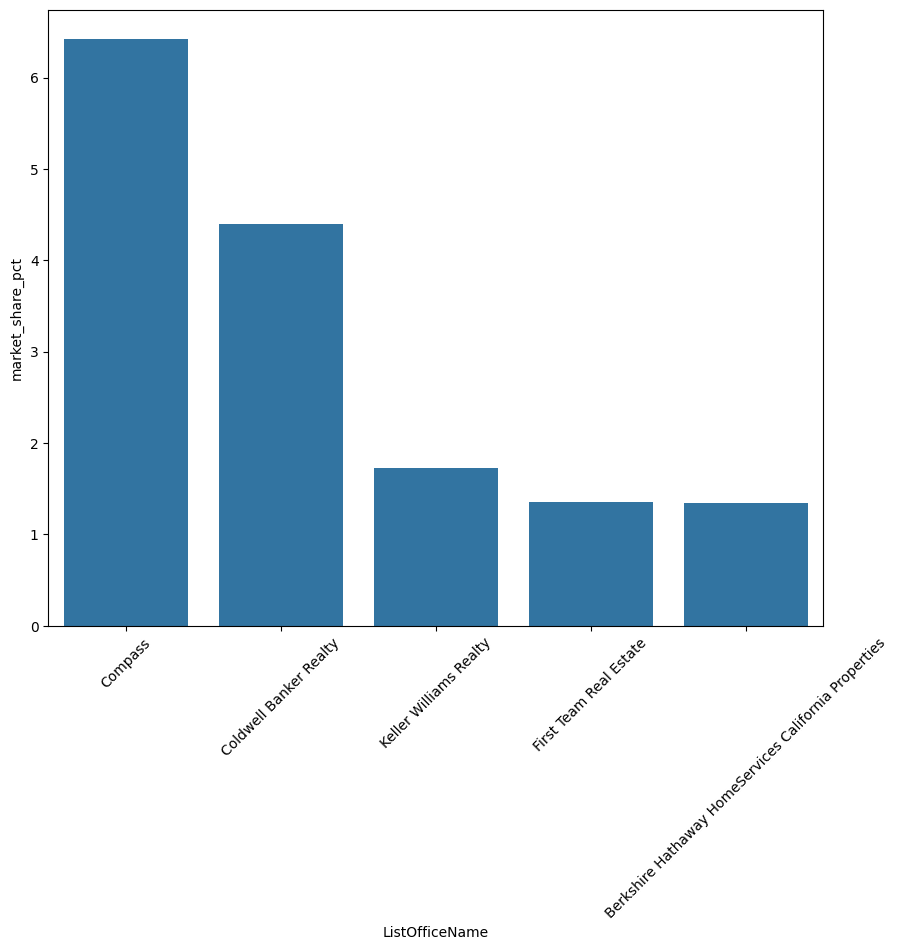

In [94]:
plt.figure(figsize=(10, 8))
sns.barplot(x='ListOfficeName', y='market_share_pct', data=largest_market)
plt.xticks(rotation=45)
plt.show()

B. Premium vs. Discount

In [95]:
listing_office_summary['premium_discount_pct'] = (
    (listing_office_summary['avg_sale_to_list'] - 1) * 100
)

In [96]:
listing_office_summary[listing_office_summary['premium_discount_pct'] < 0].head()

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
10,Sotheby's International Realty,3433,3433,4.286040e+09,915000.0,52.307020,0.972052,29.0,915000.0,4.286040e+09,0.586554,-2.794809
14,Carolwood Estates,924,924,2.990080e+09,1330000.0,51.335498,0.942988,35.0,1330000.0,2.990080e+09,0.157872,-5.701234
22,Redfin Corporation,2627,2627,2.373981e+09,790000.0,32.362391,0.986271,18.0,790000.0,2.373981e+09,0.448843,-1.372934
24,"Douglas Elliman of California, Inc.",1089,1089,2.008727e+09,875000.0,40.531680,0.978783,23.0,875000.0,2.008727e+09,0.186064,-2.121733
26,The Beverly Hills Estates,653,653,1.722850e+09,850000.0,55.249617,0.946778,38.0,850000.0,1.722850e+09,0.111570,-5.322236


In [97]:
listing_office_summary[listing_office_summary['premium_discount_pct'] > 0].head()

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
0,Compass,37590,37590,5.260893e+10,1040000.0,34.766693,1.198263,17.0,1040000.0,5.260893e+10,6.422534,19.826273
1,Coldwell Banker Realty,25715,25715,2.989594e+10,868000.0,38.165429,4.979016,19.0,868000.0,2.989594e+10,4.393601,397.901614
2,Berkshire Hathaway HomeServices California Pro...,7829,7829,8.799772e+09,735000.0,44.311279,1.111411,25.0,735000.0,8.799772e+09,1.337643,11.141097
3,Keller Williams Realty,10084,10084,8.730361e+09,783938.0,32.877330,1.849741,16.0,783938.0,8.730361e+09,1.722927,84.974135
4,Intero Real Estate Services,4588,4588,7.127879e+09,1305000.0,28.122711,3.465897,12.0,1305000.0,7.127879e+09,0.783894,246.589721


In [98]:
largest_premium = listing_office_summary[listing_office_summary['premium_discount_pct'] != float('inf')].nlargest(5, 'premium_discount_pct')

In [99]:
largest_premium

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
10615,Millennium Homes & Estates,3,3,2385000.0,620000.0,82.000000,321795.452771,74.0,620000.0,2385000.0,0.000513,3.217945e+07
9344,Conolan Realty,4,4,3008000.0,837500.0,25.500000,223409.734151,25.5,837500.0,3008000.0,0.000683,2.234087e+07
6381,NATALIE WILSON REAL ESTATE SERVICES,17,17,5552170.0,279000.0,55.647059,56150.625737,55.0,279000.0,5552170.0,0.002905,5.614963e+06
9798,Apoorva Realty,4,4,2763899.0,879999.5,41.500000,25000.747771,41.5,879999.5,2763899.0,0.000683,2.499975e+06
1385,"Drive Real Estate, Inc.",74,74,38191736.0,472500.0,35.243243,19595.541416,25.5,472500.0,38191736.0,0.012643,1.959454e+06


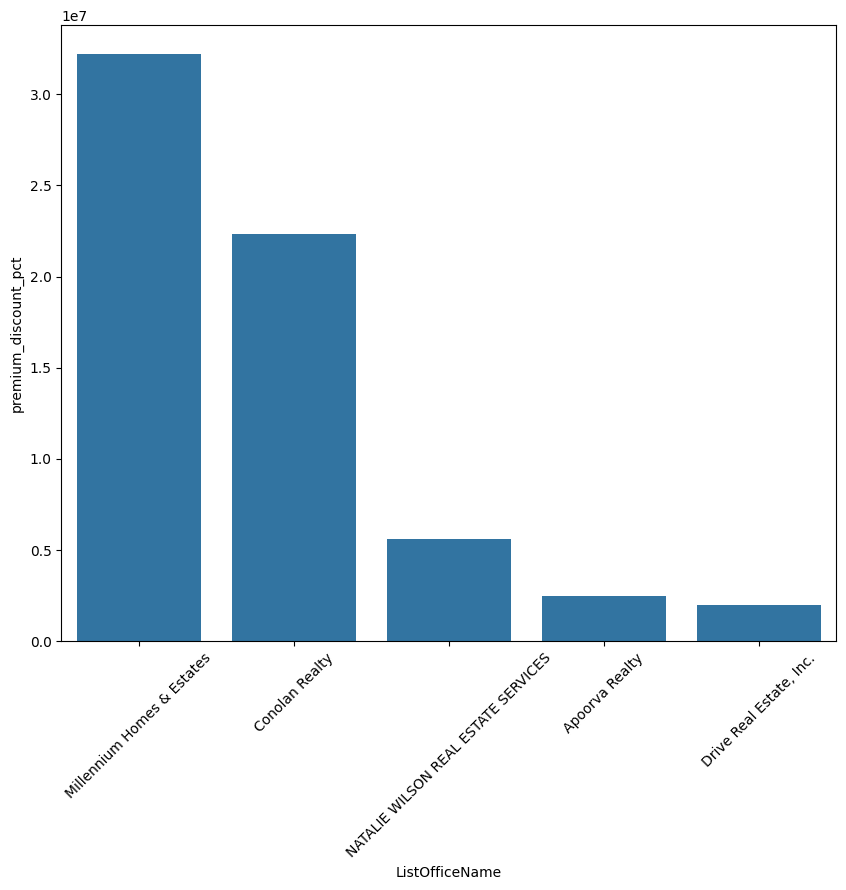

In [100]:
plt.figure(figsize=(10, 8))
sns.barplot(x='ListOfficeName', y='premium_discount_pct', data=largest_premium)
plt.xticks(rotation=45)
plt.show()

In [101]:
smallest_premium = listing_office_summary.nsmallest(5, 'premium_discount_pct')
smallest_premium

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
21389,World Funding Company,1,1,0.00,0.00,20.0,0.000000,20.0,0.00,0.00,0.000171,-100.000000
21390,"Robert Honer, Broker",1,1,0.00,0.00,26.0,0.000000,26.0,0.00,0.00,0.000171,-100.000000
21391,Elite Realty Agents,1,1,0.00,0.00,1.0,0.000000,1.0,0.00,0.00,0.000171,-100.000000
21388,Altman Apartments LLC,1,1,2.12,2.12,96.0,0.000356,96.0,2.12,2.12,0.000171,-99.964370
14813,Mayer Makabe,1,1,1100000.00,1100000.00,79.0,0.000845,79.0,1100000.00,1100000.00,0.000171,-99.915515


C. Efficiency Score

In [102]:
listing_office_summary['efficiency_score'] = (
    listing_office_summary['avg_sale_to_list']
    / listing_office_summary['median_dom']
)

In [103]:
listing_office_summary[listing_office_summary['efficiency_score'] != float('inf')]['efficiency_score'].describe()

count    21193.000000
mean         0.955044
std         68.344139
min          0.000000
25%          0.021485
50%          0.039964
75%          0.072847
max       8761.166045
Name: efficiency_score, dtype: float64

In [104]:
top_efficiency = (
    listing_office_summary.sort_values(
        by='efficiency_score',
        ascending=False
    )
)

top_efficiency[top_efficiency['efficiency_score'] != float('inf')].nlargest(5, 'efficiency_score')

,ListOfficeName,sales_count,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct,efficiency_score
9344,Conolan Realty,4,4,3008000.0,837500.0,25.500000,223409.734151,25.5,837500.0,3008000.0,0.000683,2.234087e+07,8761.166045
10615,Millennium Homes & Estates,3,3,2385000.0,620000.0,82.000000,321795.452771,74.0,620000.0,2385000.0,0.000513,3.217945e+07,4348.587200
6381,NATALIE WILSON REAL ESTATE SERVICES,17,17,5552170.0,279000.0,55.647059,56150.625737,55.0,279000.0,5552170.0,0.002905,5.614963e+06,1020.920468
1252,First Family Homes,60,60,43462177.0,695750.0,33.900000,16204.661093,18.5,695750.0,43462177.0,0.010251,1.620366e+06,875.927627
1385,"Drive Real Estate, Inc.",74,74,38191736.0,472500.0,35.243243,19595.541416,25.5,472500.0,38191736.0,0.012643,1.959454e+06,768.452605


D. Luxury Brokerage

In [105]:
# Define luxury threshold (top 10%)

luxury_threshold = (
    sold_cleaned_df['ClosePrice']
    .quantile(0.90)
)
luxury_threshold

np.float64(1780000.0)

In [106]:
# Filter luxury listings

luxury_listings = sold_cleaned_df[
    sold_cleaned_df['ClosePrice'] >= luxury_threshold
]
len(luxury_listings)

58600

In [107]:
luxury_office_summary = (
    luxury_listings.groupby('ListOfficeName')
    .agg(
        luxury_sales=('ClosePrice', 'count'),

        avg_luxury_price=('ClosePrice', 'mean'),

        median_luxury_dom=('DaysOnMarket', 'median')
    )
    .reset_index()
)

In [108]:
luxury_office_summary

,ListOfficeName,luxury_sales,avg_luxury_price,median_luxury_dom
0,1 Percent Lists SoCal,1,1825000.0,6.0
1,1% LISTING FEE,1,2390000.0,35.0
2,1% Listing Broker,1,1912500.0,9.0
3,10-8 Real Estate,2,2350000.0,21.0
4,1000 Realty Corporation,1,2800000.0,27.0
...,...,...,...,...
5436,iValue,1,2200000.0,3.0
5437,reframe,2,1991500.0,43.0
5438,smithREgroup,1,2200000.0,145.0
5439,socalhomeshop Inc.,1,1800000.0,47.0


In [109]:
# Keep offices with enough luxury transactions

luxury_office_summary = luxury_office_summary[
    luxury_office_summary['luxury_sales'] >= 5
]

print("\nTOP LUXURY OFFICES")
print(
    luxury_office_summary.sort_values(
        by='luxury_sales',
        ascending=False
    ).head(10)
)


TOP LUXURY OFFICES
                                         ListOfficeName  luxury_sales  \
1176                                            Compass          9585   
1140                             Coldwell Banker Realty          4980   
2267                        Intero Real Estate Services          1376   
526   Berkshire Hathaway HomeServices California Pro...          1358   
4782                                         The Agency          1291   
3475                     Pacific Sotheby's Int'l Realty           809   
4532                     Sotheby's International Realty           799   
2566                             Keller Williams Realty           748   
1028        Christie's International Real Estate Sereno           744   
1739                             First Team Real Estate           690   

      avg_luxury_price  median_luxury_dom  
1176      3.366555e+06               14.0  
1140      3.206454e+06               14.0  
2267      2.865202e+06                8.0  


In [110]:
largest_luxury = luxury_office_summary.nlargest(5, 'luxury_sales')

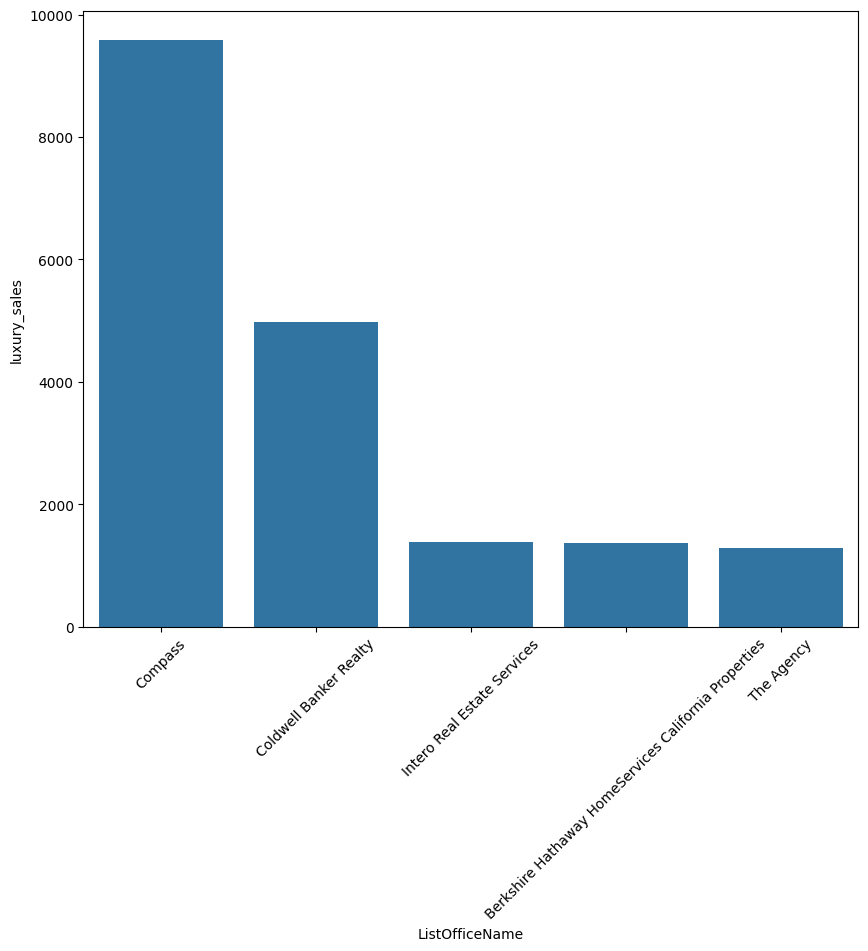

In [111]:
plt.figure(figsize=(10, 8))
sns.barplot(x='ListOfficeName', y='luxury_sales', data=largest_luxury)
plt.xticks(rotation=45)
plt.show()

E. Geographic Specialization

In [112]:
office_geo_summary = (
    sold_cleaned_df.groupby(
        ['ListOfficeName', 'MLSAreaMajor']
    )
    .agg(
        sales_count=('ClosePrice', 'count'),

        avg_close_price=('ClosePrice', 'mean'),

        median_dom=('DaysOnMarket', 'median')
    )
    .reset_index()
)

print("\nOFFICE GEOGRAPHIC SPECIALIZATION")
print(office_geo_summary.head())


OFFICE GEOGRAPHIC SPECIALIZATION
               ListOfficeName                        MLSAreaMajor  \
0  #1 FLAT FEE-LIBERTY REALTY                   682 - Chino Hills   
1           #1 Home SalesÃÂ®                   699 - Not Defined   
2           #1 Home SalesÃÂ®  SRCAR - Southwest Riverside County   
3        #1 Realty Homes Inc.             322 - North Palm Desert   
4        #1 Realty Homes Inc.          335 - Cathedral City North   

   sales_count  avg_close_price  median_dom  
0            3    843333.333333        24.0  
1            1    835000.000000        95.0  
2            2    556000.000000        15.5  
3            1      3200.000000         0.0  
4            1      3300.000000         0.0  


In [113]:
office_geo_summary.nlargest(5, 'avg_close_price')

,ListOfficeName,MLSAreaMajor,sales_count,avg_close_price,median_dom
4184,Alequin Properties,628 - Glendale-South of 134 Fwy,1,49000000.0,1.0
135117,Tony Azzi,C06 - Brentwood,1,46350000.0,13.0
93368,Pacific SothebyÃ¢ÂÂs International Realty,N26 - Newport Coast,1,37000000.0,22.0
75433,Land Co Development Inc,CR - Crystal Cove,2,35666500.0,41.5
139768,Village Properties,GLTA - Goleta,2,35000000.0,417.5


In [114]:
office_geo_summary.nlargest(5, 'sales_count')

,ListOfficeName,MLSAreaMajor,sales_count,avg_close_price,median_dom
32183,Compass,Missing,6169,1.382708e+06,13.0
31877,Compass,699 - Not Defined,5060,1.932598e+06,11.0
30315,Coldwell Banker Realty,699 - Not Defined,4781,1.756059e+06,12.0
60313,Intero Real Estate Services,699 - Not Defined,3511,1.665951e+06,12.0
30588,Coldwell Banker Realty,Missing,2077,1.244366e+06,13.0


F. Property Type Specialization

In [115]:
office_property_summary = (
    sold_cleaned_df.groupby(
        ['ListOfficeName', 'PropertyType']
    )
    .agg(
        sales_count=('ClosePrice', 'count'),

        avg_close_price=('ClosePrice', 'mean'),

        median_dom=('DaysOnMarket', 'median')
    )
    .reset_index()
)

print("\nOFFICE PROPERTY TYPE SPECIALIZATION")
print(office_property_summary.head())


OFFICE PROPERTY TYPE SPECIALIZATION
               ListOfficeName        PropertyType  sales_count  \
0  #1 FLAT FEE-LIBERTY REALTY         Residential            3   
1           #1 Home SalesÃÂ®         Residential            3   
2        #1 Realty Homes Inc.    ResidentialLease            5   
3                           *  ManufacturedInPark            1   
4                           *         Residential            1   

   avg_close_price  median_dom  
0    843333.333333        24.0  
1    649000.000000        18.0  
2      2380.000000         0.0  
3     90000.000000        41.0  
4    565000.000000        16.0  


In [116]:
office_property_summary.nlargest(5, 'avg_close_price')

,ListOfficeName,PropertyType,sales_count,avg_close_price,median_dom
18809,Land Co Development Inc,Residential,2,35666500.0,41.5
395,ABCO Realty and Investment,Residential,1,28500000.0,41.0
20561,Marisol Malibu Realty,Residential,1,28500000.0,265.0
18966,Laurie J. Lustig,CommercialSale,1,28000000.0,268.0
18967,Laurie J. Lustig,ResidentialIncome,1,28000000.0,111.0


In [117]:
office_property_summary.nlargest(5, 'sales_count')

,ListOfficeName,PropertyType,sales_count,avg_close_price,median_dom
7870,Compass,Residential,27855,1.797841e+06,14.0
7659,Coldwell Banker Realty,Residential,18145,1.569819e+06,16.0
7872,Compass,ResidentialLease,8085,1.133832e+04,27.0
17660,Keller Williams Realty,Residential,7964,1.023649e+06,14.0
7661,Coldwell Banker Realty,ResidentialLease,6293,9.363044e+03,24.0


G. Office Tier Classification

In [118]:
def classify_office(row):

    if row['sales_count'] > 500:
        return 'High Volume'

    elif row['median_close_price'] > 1000000:
        return 'Luxury Specialist'

    elif row['efficiency_score'] > 0.02:
        return 'High Efficiency'

    else:
        return 'Standard'


listing_office_summary['office_category'] = (
    listing_office_summary.apply(classify_office, axis=1)
)

print("\nOFFICE CATEGORIES")
print(
    listing_office_summary[
        ['ListOfficeName', 'office_category']
    ].head(20)
)


OFFICE CATEGORIES
                                       ListOfficeName office_category
0                                             Compass     High Volume
1                              Coldwell Banker Realty     High Volume
2   Berkshire Hathaway HomeServices California Pro...     High Volume
3                              Keller Williams Realty     High Volume
4                         Intero Real Estate Services     High Volume
5                              First Team Real Estate     High Volume
6                                          The Agency     High Volume
7                                         Real Broker     High Volume
8                        eXp Realty of California Inc     High Volume
9                      Pacific Sotheby's Int'l Realty     High Volume
10                     Sotheby's International Realty     High Volume
11                                       Equity Union     High Volume
12                     eXp Realty of California, Inc.     High Volume
1

H. Competitive Positioning

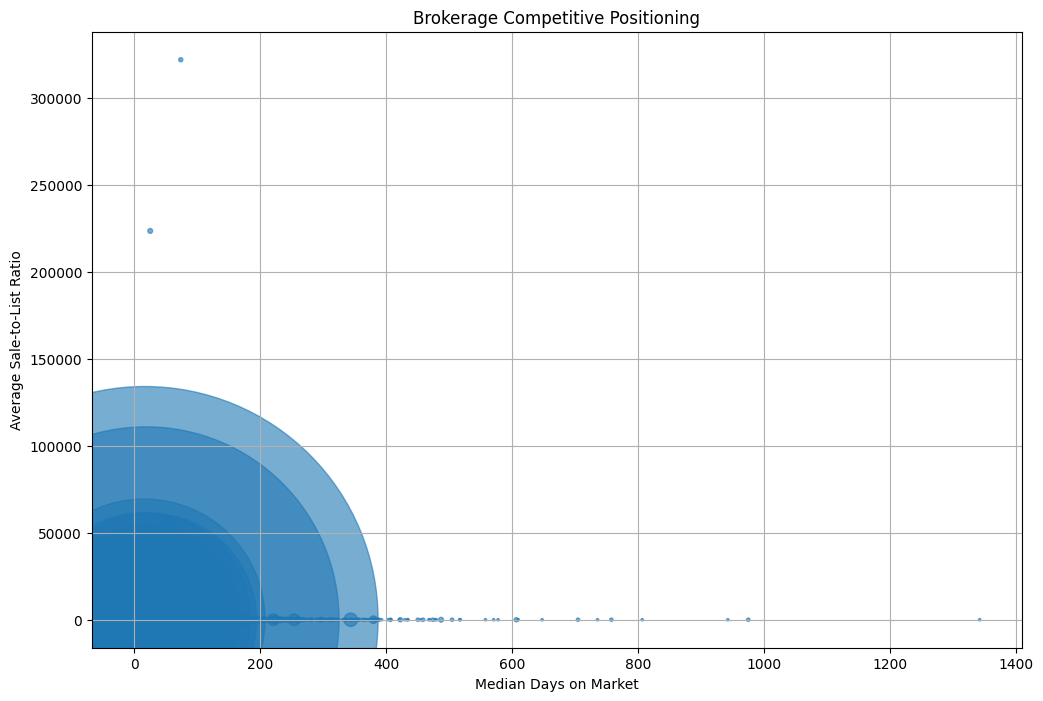

In [119]:
plt.figure(figsize=(12, 8))

plt.scatter(
    listing_office_summary['median_dom'],
    listing_office_summary['avg_sale_to_list'],

    s=listing_office_summary['sales_count'] * 3,

    alpha=0.6
)

plt.xlabel('Median Days on Market')
plt.ylabel('Average Sale-to-List Ratio')

plt.title('Brokerage Competitive Positioning')

plt.grid(True)

plt.show()

I. Top 10 Offices by Sales Volume

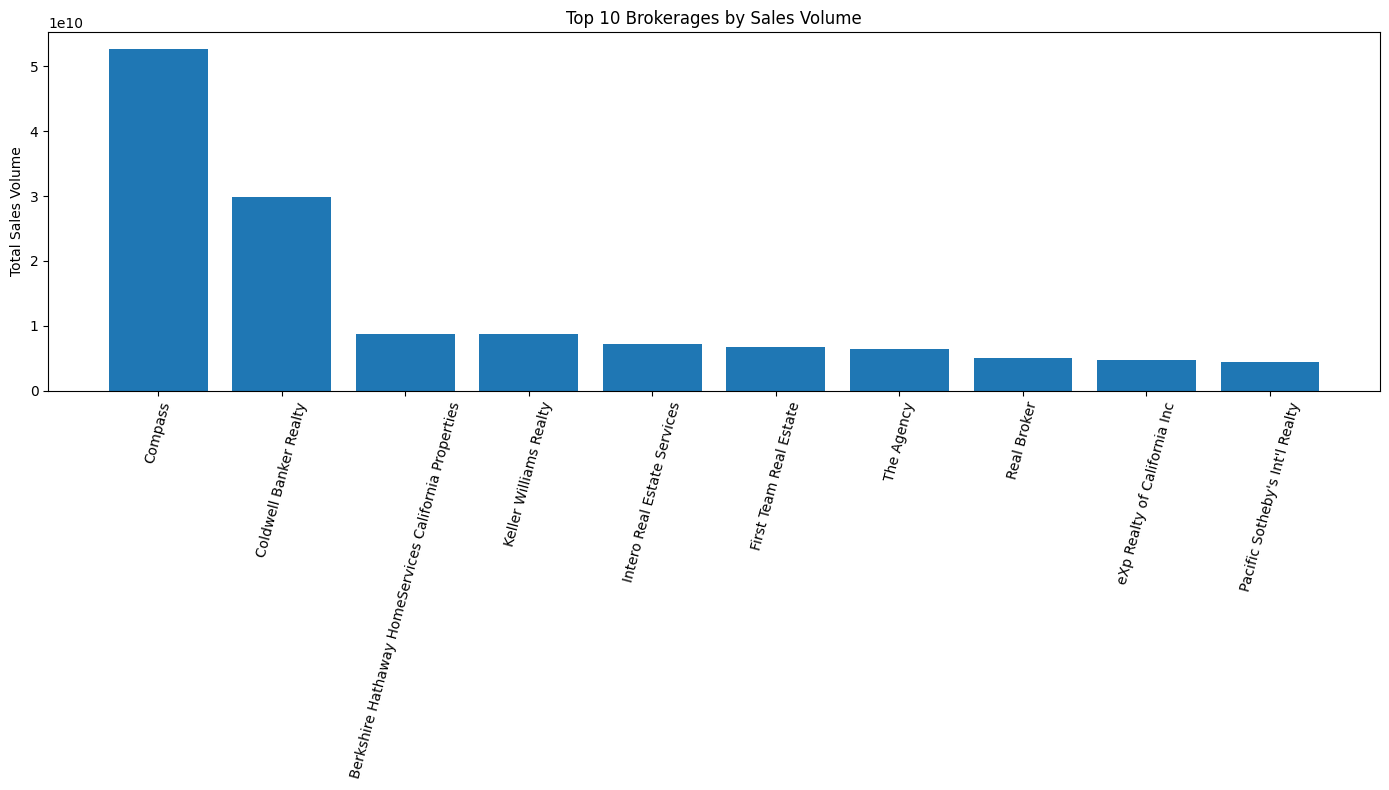

In [120]:
top_volume = (
    listing_office_summary.sort_values(
        by='total_sales_volume',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(14, 8))

plt.bar(
    top_volume['ListOfficeName'],
    top_volume['total_sales_volume']
)

plt.xticks(rotation=75)

plt.ylabel('Total Sales Volume')

plt.title('Top 10 Brokerages by Sales Volume')

plt.tight_layout()

plt.show()

BuyerOfficeName

In [121]:
buyer_office_summary = (
    sold_cleaned_df.groupby('BuyerOfficeName')
    .agg(
        listings=('ListingId', 'count'),
        total_volume=('ClosePrice', 'sum'),
        median_sale_price=('ClosePrice', 'median'),
        avg_dom=('DaysOnMarket', 'mean'),
        avg_sale_to_list=('price_ratio', 'mean'),
        sales_count=('ClosePrice', 'count'),
        median_dom=('DaysOnMarket', 'median'),
        median_close_price=('ClosePrice', 'median'),
        total_sales_volume=('ClosePrice', 'sum')
    )
    .sort_values('total_volume', ascending=False)
    .reset_index()
)

In [122]:
buyer_office_summary[buyer_office_summary.notna()].head()

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume
0,Compass,36009,4.854582e+10,1005000.0,35.844233,1.585603,36009,18.0,1005000.0,4.854582e+10
1,Coldwell Banker Realty,21606,2.406632e+10,810000.0,37.746135,1.355920,21606,19.0,810000.0,2.406632e+10
2,Missing,6736,8.414657e+09,1042500.0,36.094863,1.008002,6736,16.0,1042500.0,8.414657e+09
3,Keller Williams Realty,8295,6.819191e+09,712000.0,35.931887,1.792146,8295,19.0,712000.0,6.819191e+09
4,Berkshire Hathaway HomeServices California Pro...,6326,6.796073e+09,720000.0,42.773316,1.229894,6326,24.0,720000.0,6.796073e+09


A. Brokerage Performance

In [123]:
buyer_office_summary['avg_sale_to_list'].describe()

C:\Users\mayab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    2.392800e+04
mean              inf
std               NaN
min      0.000000e+00
25%      9.515312e-01
50%      9.805719e-01
75%      1.000407e+00
max               inf
Name: avg_sale_to_list, dtype: float64

In [124]:
buyer_office_summary[buyer_office_summary['avg_sale_to_list'] != float('inf')].nlargest(10, 'avg_sale_to_list')

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume
5742,Blue Lotus Realty,7,6687204.0,915001.0,39.428571,146556.934646,7,33.0,915001.0,6687204.0
14013,Sonnek Realty,7,1534400.0,4300.0,22.285714,85715.148248,7,17.0,4300.0,1534400.0
1862,Bznuni Realty Group,23,24906278.0,760000.0,32.478261,63044.462388,23,19.0,760000.0,24906278.0
5148,Coldwell Banker Commercial Rea,6,7682676.0,505000.0,103.500000,16490.896830,6,58.0,505000.0,7682676.0
84,Pardee Properties,615,622945838.0,500000.0,41.325203,14826.999697,615,26.0,500000.0,622945838.0
7824,Stigler Homes,7,4331087.5,469000.0,22.428571,13572.315979,7,16.0,469000.0,4331087.5
995,REALTY ONE GROUP HOMELINK,95,54176706.0,540000.0,41.926316,10527.288677,95,21.0,540000.0,54176706.0
126,Keller Williams Realty Calabasas,587,475774654.0,575000.0,46.529813,3706.255781,587,28.0,575000.0,475774654.0
21011,GOLDEN INFINITY GROUP,1,409500.0,409500.0,10.000000,3150.000000,1,10.0,409500.0,409500.0
293,RE/MAX New Dimension,311,197777358.0,611785.0,35.389068,3041.967868,311,20.0,611785.0,197777358.0


In [125]:
buyer_office_summary['market_share_pct'] = (
    buyer_office_summary['sales_count']
    / buyer_office_summary['sales_count'].sum()
) * 100

In [126]:
avg_market = buyer_office_summary.groupby('BuyerOfficeName')['market_share_pct'].mean().reset_index()
avg_market.head()

,BuyerOfficeName,market_share_pct
0,#1 Realty Homes Inc.,0.000854
1,& Company Real Estate,0.000513
2,*,0.000854
3,", Inc",0.000171
4,01718402,0.000171


In [127]:
buyer_office_summary.nlargest(5, 'market_share_pct')

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume,market_share_pct
0,Compass,36009,4.854582e+10,1005000.0,35.844233,1.585603,36009,18.0,1005000.0,4.854582e+10,6.152408
1,Coldwell Banker Realty,21606,2.406632e+10,810000.0,37.746135,1.355920,21606,19.0,810000.0,2.406632e+10,3.691548
6,NONMEMBER MRML,11576,6.265919e+09,435000.0,49.612820,inf,11576,28.0,435000.0,6.265919e+09,1.977847
23,None MRML,8319,2.223919e+09,4500.0,43.069960,1.220733,8319,27.0,4500.0,2.223919e+09,1.421364
3,Keller Williams Realty,8295,6.819191e+09,712000.0,35.931887,1.792146,8295,19.0,712000.0,6.819191e+09,1.417263


In [128]:
largest_market = avg_market.nlargest(5, 'market_share_pct')
largest_market

,BuyerOfficeName,market_share_pct
5065,Compass,6.152408
4955,Coldwell Banker Realty,3.691548
14384,NONMEMBER MRML,1.977847
14872,None MRML,1.421364
11438,Keller Williams Realty,1.417263


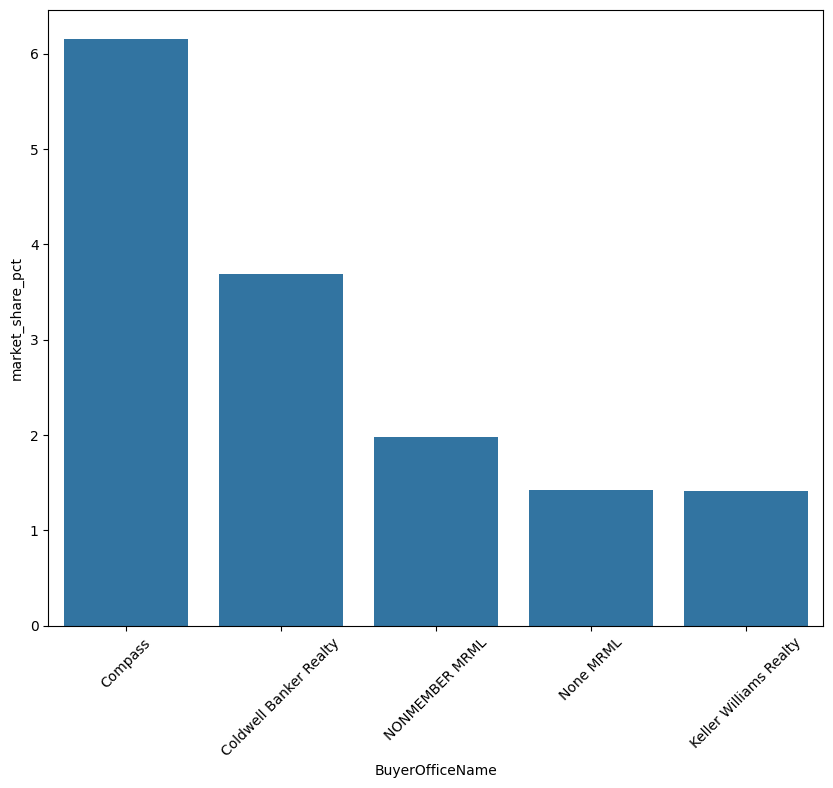

In [129]:
plt.figure(figsize=(10, 8))
sns.barplot(x='BuyerOfficeName', y='market_share_pct', data=largest_market)
plt.xticks(rotation=45)
plt.show()

B. Premium vs. Discount

In [130]:
buyer_office_summary['premium_discount_pct'] = (
    (buyer_office_summary['avg_sale_to_list'] - 1) * 100
)

In [131]:
buyer_office_summary[buyer_office_summary['premium_discount_pct'] < 0].head()

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
14,Sotheby's International Realty,3103,3.630504e+09,785000.0,51.633580,0.969075,3103,28.0,785000.0,3.630504e+09,0.530171,-3.092463
22,Carolwood Estates,931,2.372023e+09,962000.0,46.520945,0.960075,931,29.0,962000.0,2.372023e+09,0.159068,-3.992466
26,"Pinnacle Estate Properties, Inc.",2145,1.740418e+09,770000.0,40.075058,0.996539,2145,25.0,770000.0,1.740418e+09,0.366489,-0.346057
27,Non-Participant Office,1909,1.694067e+09,6750.0,56.411734,0.956202,1909,34.0,6750.0,1.694067e+09,0.326167,-4.379838
31,The Beverly Hills Estates,721,1.553005e+09,670000.0,53.876560,0.953176,721,34.0,670000.0,1.553005e+09,0.123188,-4.682354


In [132]:
buyer_office_summary[buyer_office_summary['premium_discount_pct'] > 0].head()

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
0,Compass,36009,4.854582e+10,1005000.0,35.844233,1.585603,36009,18.0,1005000.0,4.854582e+10,6.152408,58.560254
1,Coldwell Banker Realty,21606,2.406632e+10,810000.0,37.746135,1.355920,21606,19.0,810000.0,2.406632e+10,3.691548,35.592049
2,Missing,6736,8.414657e+09,1042500.0,36.094863,1.008002,6736,16.0,1042500.0,8.414657e+09,1.150896,0.800221
3,Keller Williams Realty,8295,6.819191e+09,712000.0,35.931887,1.792146,8295,19.0,712000.0,6.819191e+09,1.417263,79.214561
4,Berkshire Hathaway HomeServices California Pro...,6326,6.796073e+09,720000.0,42.773316,1.229894,6326,24.0,720000.0,6.796073e+09,1.080845,22.989419


In [133]:
largest_premium = buyer_office_summary[buyer_office_summary['premium_discount_pct'] != float('inf')].nlargest(5, 'premium_discount_pct')
largest_premium

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
5742,Blue Lotus Realty,7,6687204.0,915001.0,39.428571,146556.934646,7,33.0,915001.0,6687204.0,0.001196,1.465559e+07
14013,Sonnek Realty,7,1534400.0,4300.0,22.285714,85715.148248,7,17.0,4300.0,1534400.0,0.001196,8.571415e+06
1862,Bznuni Realty Group,23,24906278.0,760000.0,32.478261,63044.462388,23,19.0,760000.0,24906278.0,0.003930,6.304346e+06
5148,Coldwell Banker Commercial Rea,6,7682676.0,505000.0,103.500000,16490.896830,6,58.0,505000.0,7682676.0,0.001025,1.648990e+06
84,Pardee Properties,615,622945838.0,500000.0,41.325203,14826.999697,615,26.0,500000.0,622945838.0,0.105077,1.482600e+06


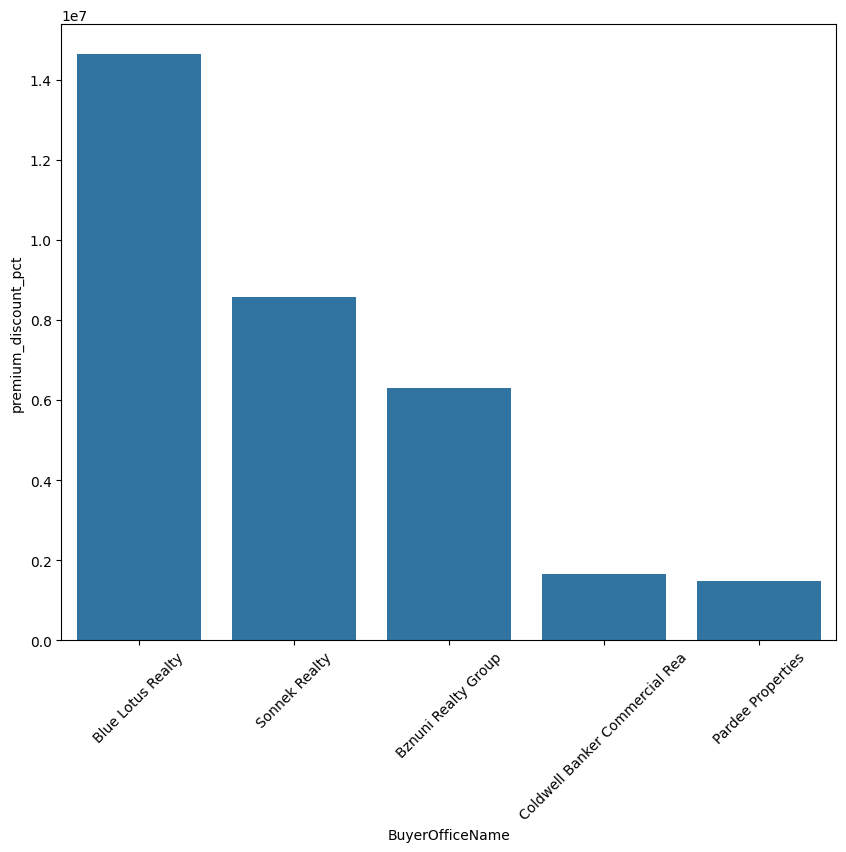

In [134]:
plt.figure(figsize=(10, 8))
sns.barplot(x='BuyerOfficeName', y='premium_discount_pct', data=largest_premium)
plt.xticks(rotation=45)
plt.show()

In [135]:
smallest_premium = buyer_office_summary.nsmallest(5, 'premium_discount_pct')
smallest_premium

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct
23926,World Funding Company,1,0.00,0.00,20.0,0.000000,1,20.0,0.00,0.00,0.000171,-100.000000
23927,C21 Realty Masters,1,0.00,0.00,25.0,0.000000,1,25.0,0.00,0.00,0.000171,-100.000000
23924,Altman Apartments LLC,1,2.12,2.12,96.0,0.000356,1,96.0,2.12,2.12,0.000171,-99.964370
23037,Pacific Venture Properties,1,6500.00,6500.00,16.0,0.000949,1,16.0,6500.00,6500.00,0.000171,-99.905109
23818,William Buzzell,1,2300.00,2300.00,13.0,0.000960,1,13.0,2300.00,2300.00,0.000171,-99.903967


C. Efficiency Score

In [136]:
buyer_office_summary['efficiency_score'] = (
    buyer_office_summary['avg_sale_to_list']
    / buyer_office_summary['median_dom']
)

In [137]:
buyer_office_summary[buyer_office_summary['efficiency_score'] != float('inf')]['efficiency_score'].describe()

count    23667.000000
mean         0.782045
std         49.394641
min          0.000000
25%          0.022561
50%          0.041873
75%          0.076405
max       5042.067544
Name: efficiency_score, dtype: float64

In [138]:
top_efficiency = (
    buyer_office_summary.sort_values(
        by='efficiency_score',
        ascending=False
    )
)


In [139]:
top_efficiency[top_efficiency['efficiency_score'] != float('inf')].nlargest(5, 'efficiency_score')

,BuyerOfficeName,listings,total_volume,median_sale_price,avg_dom,avg_sale_to_list,sales_count,median_dom,median_close_price,total_sales_volume,market_share_pct,premium_discount_pct,efficiency_score
14013,Sonnek Realty,7,1534400.0,4300.0,22.285714,85715.148248,7,17.0,4300.0,1534400.0,0.001196,8.571415e+06,5042.067544
5742,Blue Lotus Realty,7,6687204.0,915001.0,39.428571,146556.934646,7,33.0,915001.0,6687204.0,0.001196,1.465559e+07,4441.119232
1862,Bznuni Realty Group,23,24906278.0,760000.0,32.478261,63044.462388,23,19.0,760000.0,24906278.0,0.003930,6.304346e+06,3318.129599
7824,Stigler Homes,7,4331087.5,469000.0,22.428571,13572.315979,7,16.0,469000.0,4331087.5,0.001196,1.357132e+06,848.269749
84,Pardee Properties,615,622945838.0,500000.0,41.325203,14826.999697,615,26.0,500000.0,622945838.0,0.105077,1.482600e+06,570.269219


D. Luxury Brokerage

In [140]:
# Define luxury threshold (top 10%)

luxury_threshold = (
    sold_cleaned_df['ClosePrice']
    .quantile(0.90)
)
luxury_threshold


np.float64(1780000.0)

In [141]:
# Filter luxury listings

luxury_listings = sold_cleaned_df[
    sold_cleaned_df['ClosePrice'] >= luxury_threshold
]
len(luxury_listings)

luxury_office_summary = (
    luxury_listings.groupby('BuyerOfficeName')
    .agg(
        luxury_sales=('ClosePrice', 'count'),

        avg_luxury_price=('ClosePrice', 'mean'),

        median_luxury_dom=('DaysOnMarket', 'median')
    )
    .reset_index()
)

luxury_office_summary

,BuyerOfficeName,luxury_sales,avg_luxury_price,median_luxury_dom
0,", Inc",1,2225000.0,4.0
1,1 Percent Lists SoCal,2,2425000.0,84.0
2,1000 Realty Corporation,1,2800000.0,27.0
3,"101 Realty, Inc.",1,4800000.0,30.0
4,1031 Exchange Group,2,2089000.0,96.0
...,...,...,...,...
6491,kw pacific estates,1,2368880.0,18.0
6492,redfin corporation,1,2450000.0,132.0
6493,reframe,5,2311600.0,35.0
6494,socalhomeshop Inc.,1,1800000.0,47.0


In [142]:
# Keep offices with enough luxury transactions

luxury_office_summary = luxury_office_summary[
    luxury_office_summary['luxury_sales'] >= 5
]

print("\nTOP LUXURY OFFICES")
print(
    luxury_office_summary.sort_values(
        by='luxury_sales',
        ascending=False
    ).head(10)
)


TOP LUXURY OFFICES
                                        BuyerOfficeName  luxury_sales  \
1381                                            Compass          8844   
1340                             Coldwell Banker Realty          4016   
3701                                            Missing          1206   
5730                                         The Agency          1097   
645   Berkshire Hathaway HomeServices California Pro...          1043   
2681                        Intero Real Estate Services          1000   
3041                             Keller Williams Realty           667   
5454                     Sotheby's International Realty           652   
4900                                             Redfin           616   
4187                     Pacific Sotheby's Int'l Realty           571   

      avg_luxury_price  median_luxury_dom  
1381      3.298838e+06               14.0  
1340      3.248774e+06               14.0  
3701      2.778766e+06               11.0  


In [143]:
largest_luxury = luxury_office_summary.nlargest(5, 'luxury_sales')

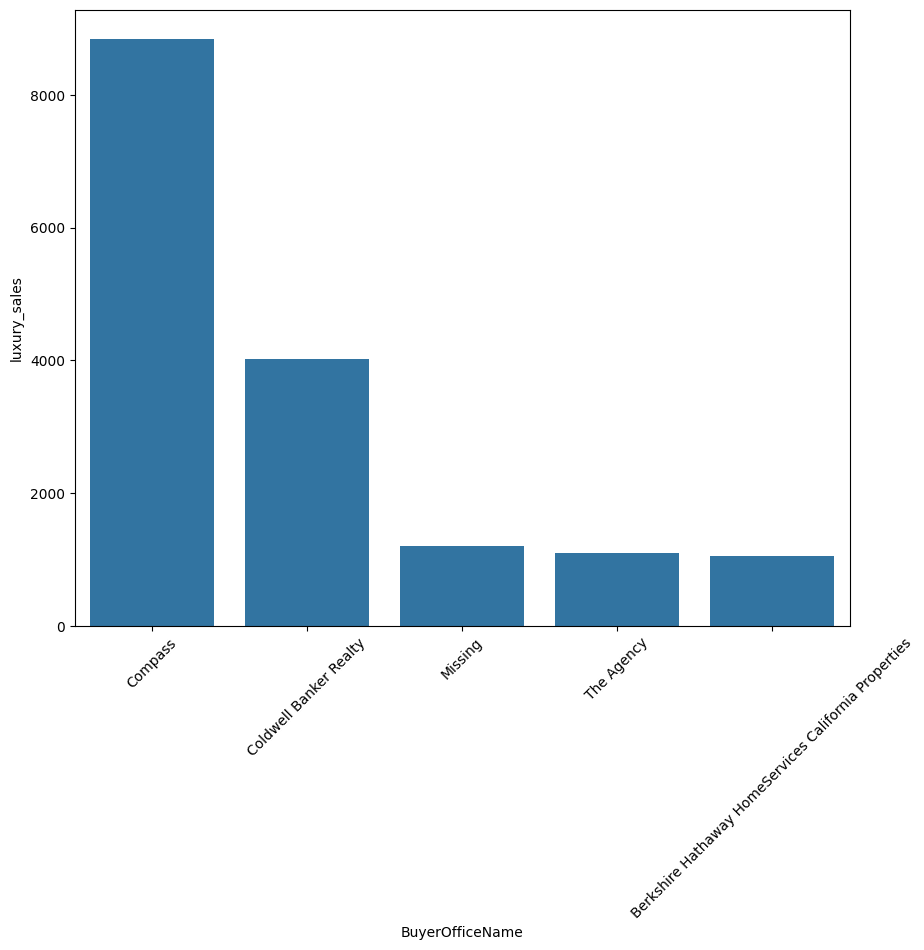

In [144]:
plt.figure(figsize=(10, 8))
sns.barplot(x='BuyerOfficeName', y='luxury_sales', data=largest_luxury)
plt.xticks(rotation=45)
plt.show()

E. Geographic Specialization

In [145]:
office_geo_summary = (
    sold_cleaned_df.groupby(
        ['BuyerOfficeName', 'MLSAreaMajor']
    )
    .agg(
        sales_count=('ClosePrice', 'count'),

        avg_close_price=('ClosePrice', 'mean'),

        median_dom=('DaysOnMarket', 'median')
    )
    .reset_index()
)

print("\nOFFICE GEOGRAPHIC SPECIALIZATION")
print(office_geo_summary.head())


OFFICE GEOGRAPHIC SPECIALIZATION
         BuyerOfficeName                   MLSAreaMajor  sales_count  \
0   #1 Realty Homes Inc.        322 - North Palm Desert            1   
1   #1 Realty Homes Inc.     335 - Cathedral City North            1   
2   #1 Realty Homes Inc.              699 - Not Defined            2   
3   #1 Realty Homes Inc.                DC591 - Landers            1   
4  & Company Real Estate  70 - Santa Ana North of First            1   

   avg_close_price  median_dom  
0           3200.0         0.0  
1           3300.0         0.0  
2           1700.0         0.0  
3           2000.0         0.0  
4        1100000.0        25.0  


In [146]:
office_geo_summary.nlargest(5, 'avg_close_price')

,BuyerOfficeName,MLSAreaMajor,sales_count,avg_close_price,median_dom
39040,David Santistevan,92003 - Bonsall,1,53000000.0,156.0
109772,Plus Real Estate,N26 - Newport Coast,1,42000000.0,0.0
96392,Newmark Residential,C32 - Malibu Beach,1,38450000.0,49.0
14584,Berkshire Hathaway HomeServices California Pro...,GLTA - Goleta,2,35000000.0,417.5
29669,Christie's International R.E. Southern California,MB - Monarch Beach,1,34000000.0,231.0


In [147]:
office_geo_summary.nlargest(5, 'sales_count')

,BuyerOfficeName,MLSAreaMajor,sales_count,avg_close_price,median_dom
91396,Missing,699 - Not Defined,5772,1.289486e+06,15.0
35571,Compass,Missing,5195,1.379711e+06,13.0
35250,Compass,699 - Not Defined,4137,1.956279e+06,12.0
33516,Coldwell Banker Realty,699 - Not Defined,3565,1.753186e+06,12.0
94252,NONMEMBER MRML,Missing,2641,4.687220e+05,27.0


F. Property Type Specialization

In [148]:
office_property_summary = (
    sold_cleaned_df.groupby(
        ['BuyerOfficeName', 'PropertyType']
    )
    .agg(
        sales_count=('ClosePrice', 'count'),

        avg_close_price=('ClosePrice', 'mean'),

        median_dom=('DaysOnMarket', 'median')
    )
    .reset_index()
)
print("\nOFFICE PROPERTY TYPE SPECIALIZATION")
print(office_property_summary.head())


OFFICE PROPERTY TYPE SPECIALIZATION
         BuyerOfficeName      PropertyType  sales_count  avg_close_price  \
0   #1 Realty Homes Inc.  ResidentialLease            5           2380.0   
1  & Company Real Estate       Residential            2         859500.0   
2  & Company Real Estate  ResidentialLease            1           3500.0   
3                      *       Residential            4         687500.0   
4                      *  ResidentialLease            1           3500.0   

   median_dom  
0         0.0  
1        15.0  
2         6.0  
3        67.5  
4        15.0  


In [149]:
office_property_summary.nlargest(5, 'avg_close_price')

,BuyerOfficeName,PropertyType,sales_count,avg_close_price,median_dom
9888,David Santistevan,Residential,2,27572500.0,94.5
25237,ORES Realty,Residential,1,27000000.0,5.0
24558,Newmark Estates,Residential,1,16750000.0,224.0
7699,Christie's AKG,CommercialSale,1,16700000.0,59.0
32090,SEAL REAL ESTATE,ResidentialIncome,1,15188888.0,52.0


In [150]:
office_property_summary.nlargest(5, 'sales_count')

,BuyerOfficeName,PropertyType,sales_count,avg_close_price,median_dom
8689,Compass,Residential,26296,1.762836e+06,15.0
8456,Coldwell Banker Realty,Residential,14511,1.579602e+06,16.0
24056,NONMEMBER MRML,Residential,8801,6.378175e+05,26.0
8691,Compass,ResidentialLease,8201,1.222532e+04,27.0
19323,Keller Williams Realty,Residential,6243,1.024160e+06,17.0


G. Office Tier Classification

In [151]:
def classify_office(row):

    if row['sales_count'] > 500:
        return 'High Volume'

    elif row['median_close_price'] > 1000000:
        return 'Luxury Specialist'

    elif row['efficiency_score'] > 0.02:
        return 'High Efficiency'

    else:
        return 'Standard'


buyer_office_summary['office_category'] = (
    buyer_office_summary.apply(classify_office, axis=1)
)

print("\nOFFICE CATEGORIES")
print(
    buyer_office_summary[
        ['BuyerOfficeName', 'office_category']
    ].head(20)
)



OFFICE CATEGORIES
                                      BuyerOfficeName office_category
0                                             Compass     High Volume
1                              Coldwell Banker Realty     High Volume
2                                             Missing     High Volume
3                              Keller Williams Realty     High Volume
4   Berkshire Hathaway HomeServices California Pro...     High Volume
5                                         Real Broker     High Volume
6                                      NONMEMBER MRML     High Volume
7                              First Team Real Estate     High Volume
8                                          The Agency     High Volume
9                        eXp Realty of California Inc     High Volume
10                        Intero Real Estate Services     High Volume
11                     eXp Realty of California, Inc.     High Volume
12                                             Redfin     High Volume
1

H. Competitive Positioning

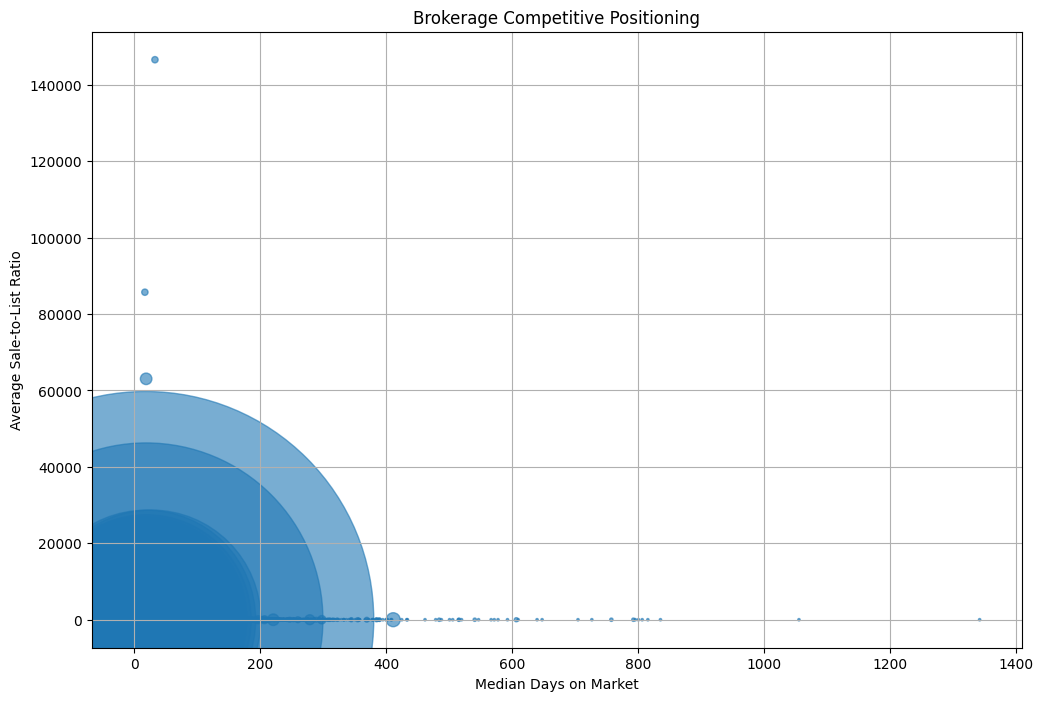

In [152]:
plt.figure(figsize=(12, 8))

plt.scatter(
    buyer_office_summary['median_dom'],
    buyer_office_summary['avg_sale_to_list'],

    s=buyer_office_summary['sales_count'] * 3,

    alpha=0.6
)

plt.xlabel('Median Days on Market')
plt.ylabel('Average Sale-to-List Ratio')

plt.title('Brokerage Competitive Positioning')

plt.grid(True)

plt.show()

I. Top 10 Offices by Sales Volume

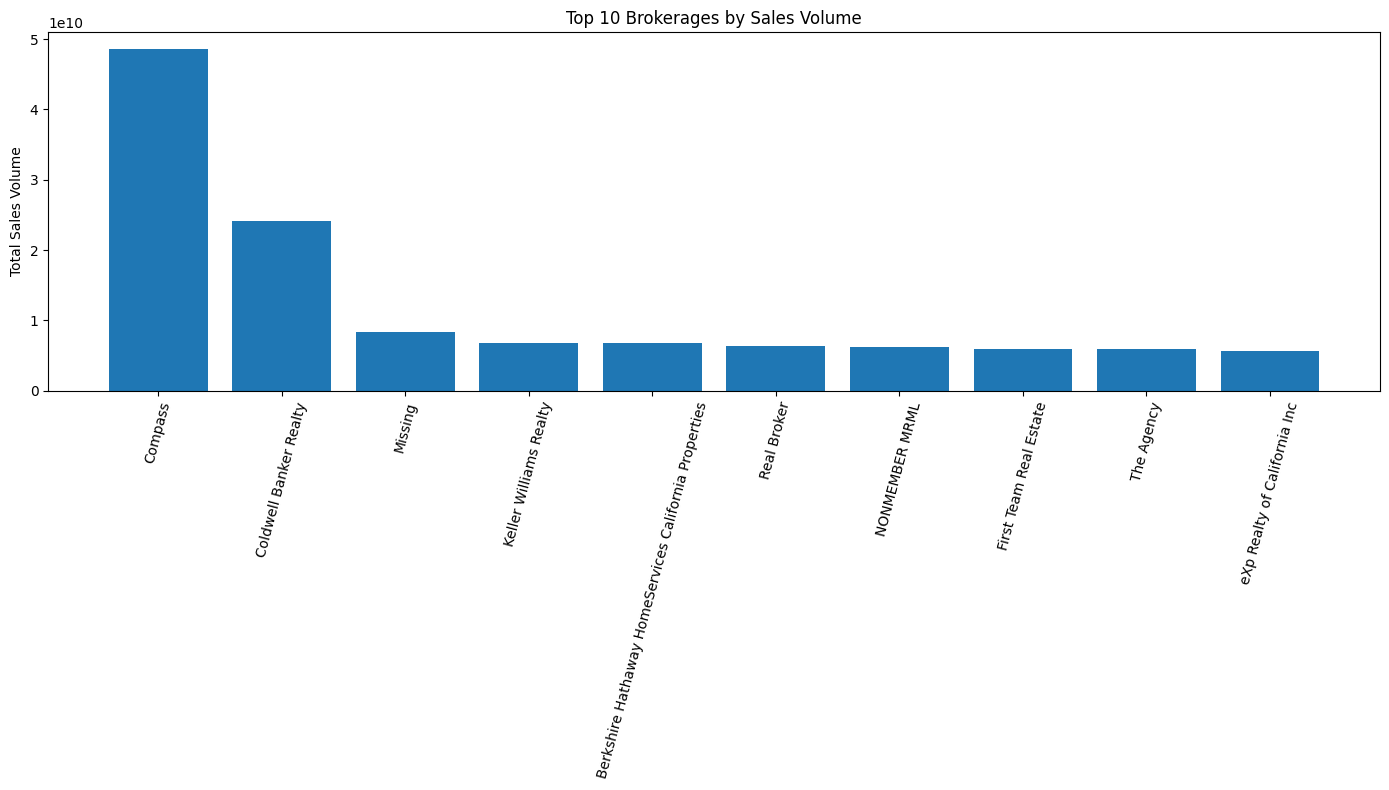

In [153]:
top_volume = (
    buyer_office_summary.sort_values(
        by='total_sales_volume',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(14, 8))

plt.bar(
    top_volume['BuyerOfficeName'],
    top_volume['total_sales_volume']
)

plt.xticks(rotation=75)

plt.ylabel('Total Sales Volume')

plt.title('Top 10 Brokerages by Sales Volume')

plt.tight_layout()

plt.show()

In [155]:
#sold_cleaned_df.to_csv("../data/Sold/sold_cleaned_df.csv", index=False)